# Exploratory Data Analysis — `demand_direct`

## 1. Setup & Data Loading

In [43]:
# System and environment
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import normaltest, skew, kurtosis
import pyarrow as pa
import pyarrow.parquet as pq

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ML utilities
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Custom color palette
COLORS = {
    'normal': '#2E7D32',  # Green
    'fraud': '#C62828',   # Red
    'primary': '#1565C0',  # Blue
    'secondary': '#FF6F00', # Orange
    'background': '#FAFAFA',
    'grid': '#E0E0E0'
}

print("📦 Libraries imported successfully")
print(f"📊 Pandas version: {pd.__version__}")
print(f"📈 NumPy version: {np.__version__}")
print(f"🎨 Matplotlib version: {plt.matplotlib.__version__}")

📦 Libraries imported successfully
📊 Pandas version: 3.0.0
📈 NumPy version: 2.3.5
🎨 Matplotlib version: 3.10.8


In [44]:
# Read data from SAS dataset
sas_data = pd.read_sas('../data/demand_direct.sas7bdat', format='sas7bdat', encoding='utf-8')

In [45]:
# save to parquet format (using pyarrow directly to avoid pandas/pyarrow compatibility issue)
table = pa.Table.from_pandas(sas_data)
pq.write_table(table, '../data/demand_direct.parquet')

del sas_data  # Free memory
print("✅ Data loaded and saved as Parquet format")

df_demand = pq.read_table('../data/demand_direct.parquet').to_pandas()
print(f'Shape: {df_demand.shape}')

✅ Data loaded and saved as Parquet format
Shape: (2386685, 42)


## 2. Data Cleaning

In [46]:
# Drop unnecessary columns
drop_cols = [
    'rf_business_name', 'rf_ext_business_name', 'a_business_name',
    'ext_business_name', 'product_type_1', 'flag_risk3', 'SCRPLUST1'
]
df_demand.drop(columns=drop_cols, inplace=True)

# Lowercase all column names
df_demand.columns = df_demand.columns.str.lower()

# Lowercase string values and replace spaces with underscores
for col in df_demand.select_dtypes(include=['object', 'string']).columns:
    df_demand[col] = (
        df_demand[col]
        .str.lower()
        .str.strip()
        .str.replace(r'\s+', '_', regex=True)
    )

# Identify column types for reuse
cat_cols = df_demand.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = [
    c for c in df_demand.select_dtypes(include='number').columns
    if c not in ['authorization_id', 'acct_booked_h0']
]

print(f"Shape after cleaning: {df_demand.shape}")
print(f"\nCategorical ({len(cat_cols)}): {cat_cols}")
print(f"\nNumerical ({len(num_cols)}): {num_cols}")


Shape after cleaning: (2386685, 35)

Categorical (14): ['customer_type', 'family_situation', 'house_type', 'reject_reason', 'status_name', 'product_type_2', 'product_type_3', 'csp', 'cpro', 'cmat', 'estcli1', 'estcli2', 'csector', 'flag_cotit']

Numerical (18): ['codrama', 'risk_score_rf', 'score_rf', 'basel_bad', 'total_amt', 'installment_amt', 'total_card_nbr', 'total_loan_nbr', 'book_card_nbr', 'book_loan_nbr', 'age_t1', 'left_to_live', 'house_years', 'tenor', 'max_credit_tj_av', 'income_t1', 'income_t2', 'incit1_l12']


## 3. Data Overview

In [47]:
df_demand.head(10)

,customer_type,family_situation,house_type,reject_reason,mis_date,status_name,authorization_id,product_type_2,product_type_3,csp,cpro,cmat,estcli1,estcli2,csector,codrama,acct_booked_h0,risk_score_rf,score_rf,basel_bad,flag_cotit,total_amt,installment_amt,total_card_nbr,total_loan_nbr,book_card_nbr,book_loan_nbr,age_t1,left_to_live,house_years,tenor,max_credit_tj_av,income_t1,income_t2,incit1_l12
0,known,married,owner,03-budget,2023-01-01,canceled,2245877377.000,known,premium,80,md,511,san,san,div,29.000,NaN,40.000,468.000,0.000,n,15000.000,197.050,2.000,2.000,0.000,0.000,32.000,825.990,6.000,96.000,8000.000,2600.000,NaN,0.000
1,known,married,owner,03-budget,2023-01-01,canceled,2255140463.000,known,premium,80,dr,460,sol,sol,div,20.000,NaN,37.000,433.000,0.000,n,4000.000,101.430,1.000,0.000,0.000,0.000,45.000,390.800,14.000,48.000,663.900,1577.000,NaN,0.000
2,known,concubine,family,04-customer_profile,2023-02-01,canceled,2294108269.000,consolidation,no_premium,80,drabs,801,sol,sol,div,10.000,NaN,76.000,397.000,0.000,n,14000.000,207.810,1.000,0.000,0.000,0.000,26.000,906.160,1.000,120.000,1.180,1512.000,NaN,0.000
3,known,married,rent,NaN,2023-01-01,canceled,2300245900.000,known,no_premium,80,dr,460,ok,ok,ban,36.000,NaN,45.000,417.000,0.000,n,10000.000,225.270,1.000,1.000,0.000,0.000,44.000,806.310,6.000,60.000,1060.780,1575.000,NaN,0.000
4,new,single,rent,NaN,2023-01-01,canceled,2316631497.000,new/inactive,hp,31,dr,900,NaN,NaN,ban,1.000,NaN,58.000,404.000,0.000,y,40000.000,550.340,0.000,0.000,0.000,0.000,43.000,2706.660,4.000,96.000,NaN,3230.000,1714.000,0.000
5,known,concubine,owner,NaN,2023-01-01,canceled,2314592376.000,consolidation,no_premium,30,drabs,801,ok,ok,ban,28.000,NaN,95.000,456.000,0.000,y,57735.000,892.570,1.000,1.000,0.000,0.000,53.000,2025.860,17.000,120.000,0.000,2559.000,1400.000,0.000
6,known,divorced,owner,NaN,2023-03-01,canceled,2309413998.000,known,no_premium,74,dm,481,ann,ann,div,13.000,NaN,22.000,416.000,0.000,n,14000.000,259.290,1.000,0.000,0.000,0.000,49.000,901.900,23.000,72.000,516.200,1900.000,NaN,3.000
7,known,married,family,09-score,2023-01-01,rejected,2309416289.000,known,no_premium,60,dm,499,san,san,div,32.000,NaN,57.000,398.000,0.000,n,18000.000,282.650,0.000,0.000,0.000,0.000,26.000,659.400,23.000,96.000,0.000,1400.000,NaN,1.000
8,known,married,owner,NaN,2023-01-01,canceled,2324851699.000,known,no_premium,60,dr,460,ok,ok,div,1.000,NaN,64.000,416.000,0.000,n,4000.000,90.330,1.000,3.000,1.000,0.000,42.000,1402.390,8.000,60.000,0.000,2318.000,NaN,0.000
9,known,concubine,owner,03-budget,2023-01-01,rejected,2322804420.000,known,no_premium,31,dr,460,sol,sol,div,28.000,NaN,95.000,416.000,0.000,n,20000.000,147.800,0.000,0.000,0.000,0.000,60.000,592.310,27.000,96.000,0.000,3007.740,NaN,0.000


In [48]:
# Missing values summary
missing = pd.DataFrame({
    'dtype': df_demand.dtypes,
    'non_null': df_demand.count(),
    'null_count': df_demand.isnull().sum(),
    'null_pct': (df_demand.isnull().mean() * 100).round(2),
    'n_unique': df_demand.nunique()
}).sort_values('null_pct', ascending=False)
missing


,dtype,non_null,null_count,null_pct,n_unique
acct_booked_h0,float64,100953,2285732,95.770,1
max_credit_tj_av,float64,1214665,1172020,49.110,159316
estcli2,str,1299300,1087385,45.560,8
estcli1,str,1326481,1060204,44.420,8
reject_reason,str,1924564,462121,19.360,9
income_t2,float64,1993586,393099,16.470,38890
codrama,float64,2340013,46672,1.960,37
risk_score_rf,float64,2380654,6031,0.250,100
basel_bad,float64,2385523,1162,0.050,2
csp,str,2386186,499,0.020,30


In [49]:
# Statistical summary of numerical variables
df_demand[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
codrama,2340013.000,15.870,10.916,0.000,8.000,13.000,27.000,42.000
risk_score_rf,2380654.000,43.042,28.610,0.000,19.000,39.000,67.000,99.000
score_rf,2386668.000,395.049,26.804,0.000,377.000,391.000,410.000,508.000
basel_bad,2385523.000,0.001,0.033,0.000,0.000,0.000,0.000,1.000
total_amt,2386685.000,11900.985,10262.388,0.000,6000.000,6500.000,15000.000,444425.000
installment_amt,2386606.000,254.961,184.956,0.000,150.590,184.330,298.410,8159.190
total_card_nbr,2386685.000,0.336,0.527,0.000,0.000,0.000,1.000,7.000
total_loan_nbr,2386685.000,0.297,0.636,0.000,0.000,0.000,0.000,51.000
book_card_nbr,2386685.000,0.030,0.190,0.000,0.000,0.000,0.000,7.000
book_loan_nbr,2386685.000,0.014,0.118,0.000,0.000,0.000,0.000,2.000


## 4. Application Status Distribution

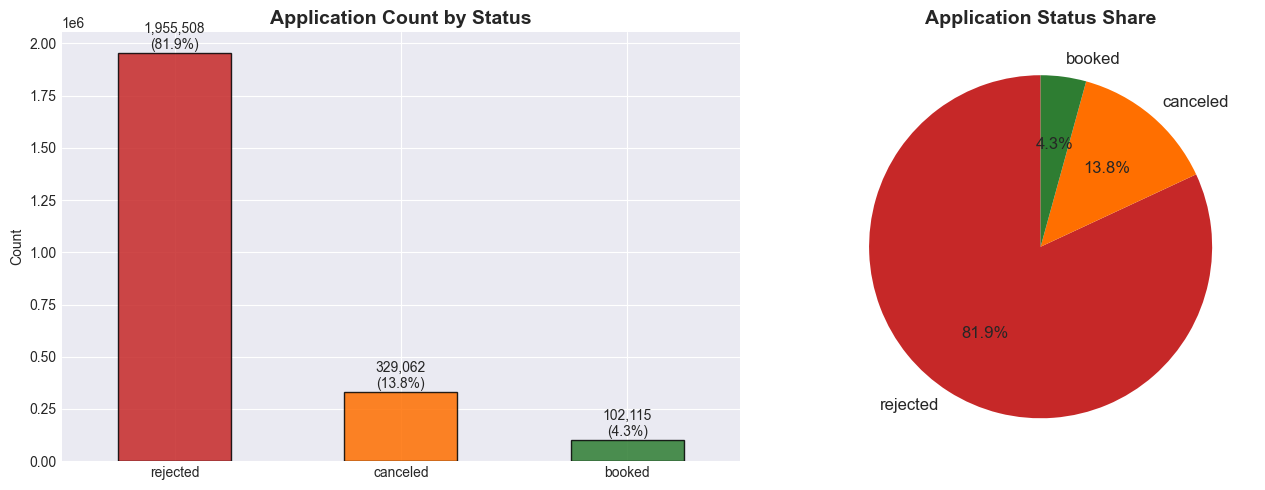


Total applications: 2,386,685
  rejected: 1,955,508 (81.9%)
  canceled: 329,062 (13.8%)
  booked: 102,115 (4.3%)


In [50]:
status_counts = df_demand['status_name'].value_counts()
status_pcts = df_demand['status_name'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
palette = {'booked': '#2E7D32', 'canceled': '#FF6F00', 'rejected': '#C62828'}
bar_colors = [palette.get(s, '#999') for s in status_counts.index]
status_counts.plot(kind='bar', ax=axes[0], color=bar_colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Application Count by Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, (v, p) in enumerate(zip(status_counts.values, status_pcts.values)):
    axes[0].text(i, v + status_counts.max() * 0.01, f'{v:,.0f}\n({p:.1f}%)',
                 ha='center', fontsize=10)

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=bar_colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Application Status Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal applications: {len(df_demand):,}")
for status in status_counts.index:
    print(f"  {status}: {status_counts[status]:,} ({status_pcts[status]:.1f}%)")


## 5. Monthly Application Trends

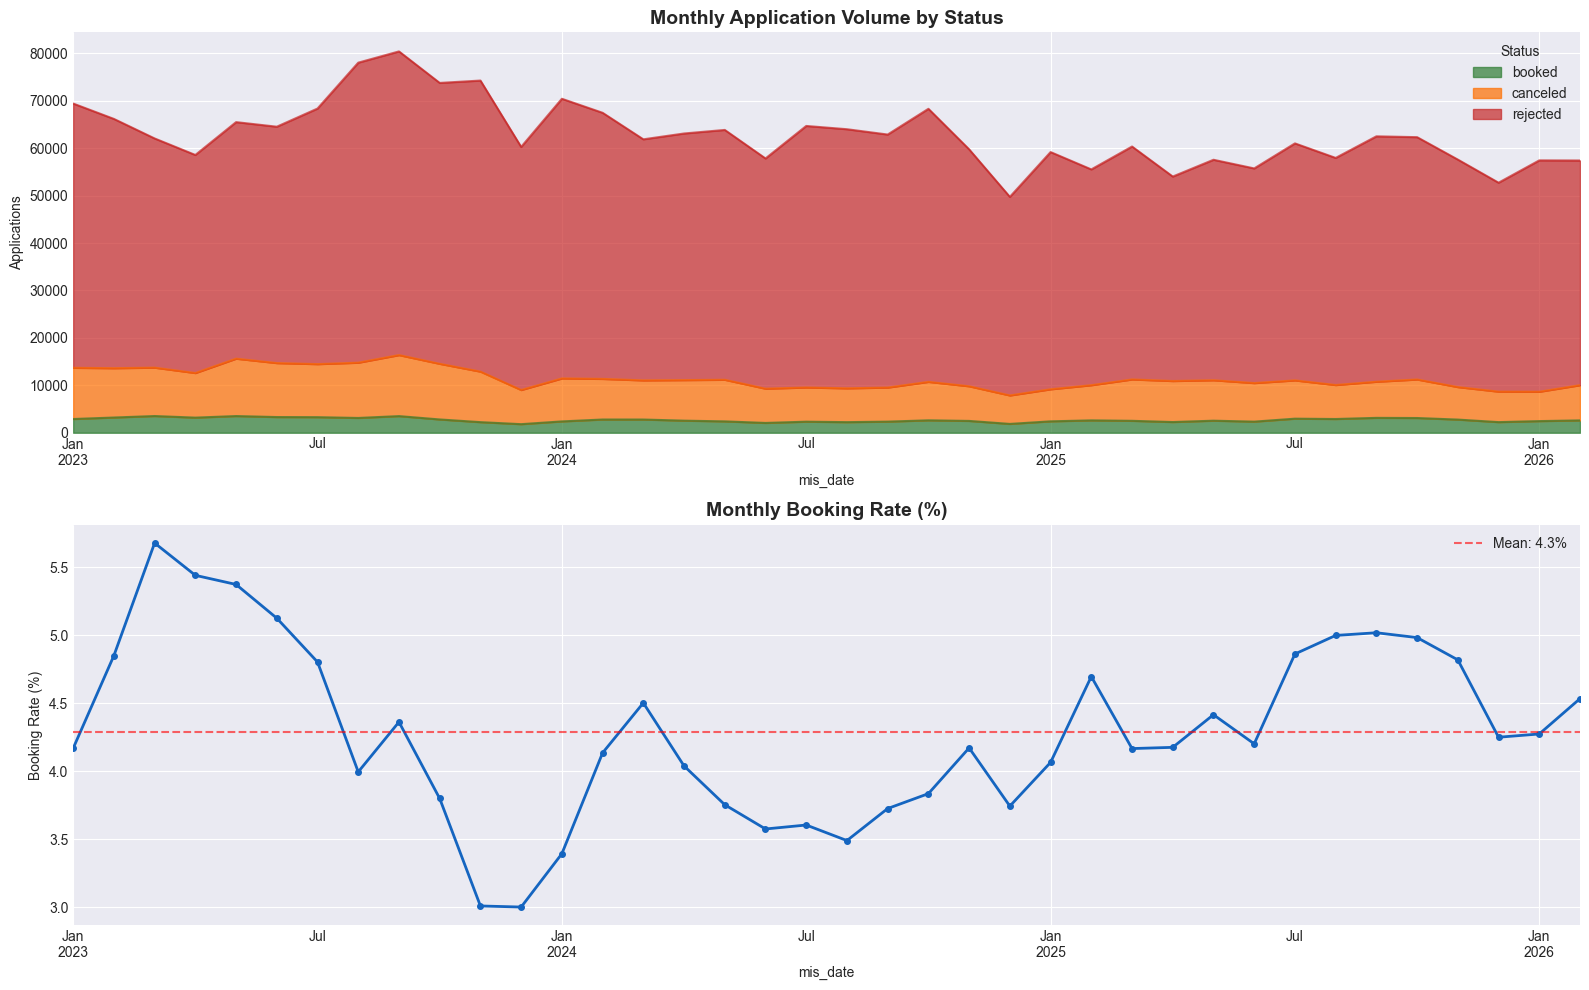

In [51]:
monthly_status = (
    df_demand
    .groupby([pd.Grouper(key='mis_date', freq='MS'), 'status_name'])
    .size()
    .unstack(fill_value=0)
)
# Reorder columns for consistent colors
col_order = [c for c in ['booked', 'canceled', 'rejected'] if c in monthly_status.columns]
monthly_status = monthly_status[col_order]
color_list = [palette[c] for c in col_order]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Stacked area
monthly_status.plot.area(ax=axes[0], color=color_list, alpha=0.7)
axes[0].set_title('Monthly Application Volume by Status', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Applications')
axes[0].legend(title='Status')

# Booking rate over time
monthly_total = monthly_status.sum(axis=1)
if 'booked' in monthly_status.columns:
    booking_rate = monthly_status['booked'] / monthly_total * 100
    booking_rate.plot(ax=axes[1], color='#1565C0', linewidth=2, marker='o', markersize=4)
    axes[1].axhline(y=booking_rate.mean(), color='red', linestyle='--', alpha=0.6,
                    label=f'Mean: {booking_rate.mean():.1f}%')
    axes[1].set_title('Monthly Booking Rate (%)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Booking Rate (%)')
    axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Reject Reason Analysis

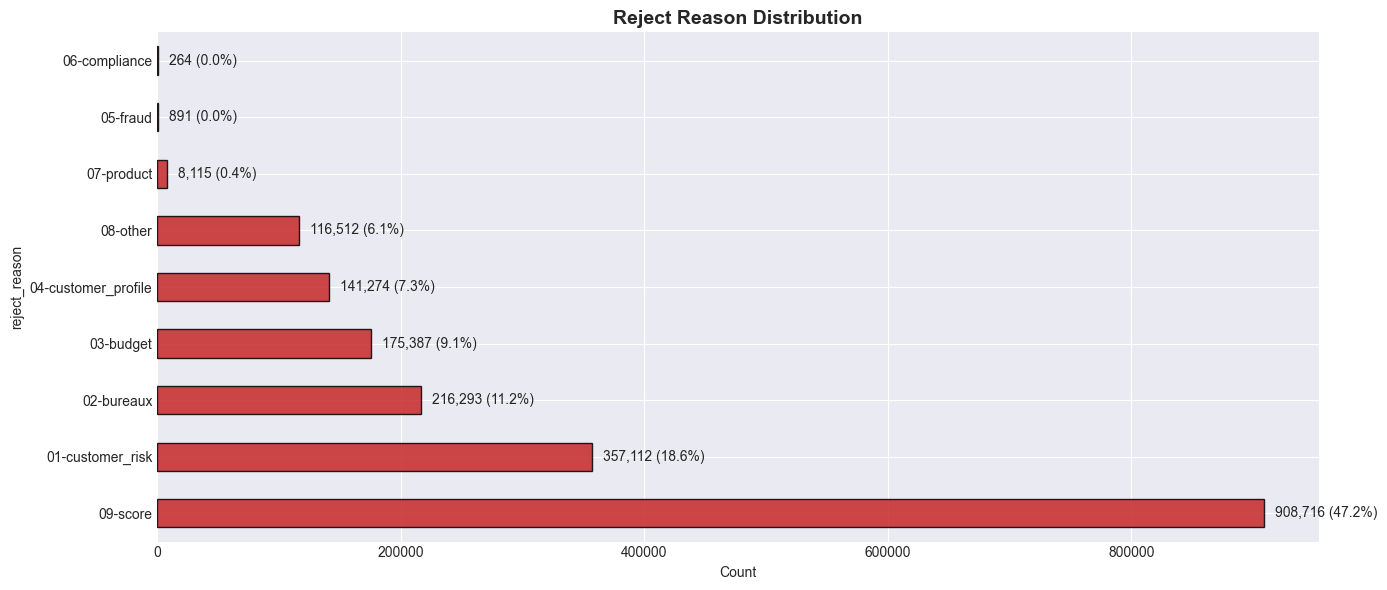


Reject reason breakdown by status:


status_name,booked,canceled,rejected,All
reject_reason,,,,
01-customer_risk,2,363,356747,357112
02-bureaux,0,121,216172,216293
03-budget,15,38123,137249,175387
04-customer_profile,0,3574,137700,141274
05-fraud,0,18,873,891
06-compliance,0,0,264,264
07-product,1,288,7826,8115
08-other,26,1476,115010,116512
09-score,29,4748,903939,908716


In [52]:
reject_df = df_demand[df_demand['reject_reason'].notna()]
reject_counts = reject_df['reject_reason'].value_counts()

fig, ax = plt.subplots(figsize=(14, 6))
reject_counts.plot(kind='barh', ax=ax, color='#C62828', edgecolor='black', alpha=0.85)
ax.set_title('Reject Reason Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
for i, v in enumerate(reject_counts.values):
    ax.text(v + reject_counts.max() * 0.01, i,
            f'{v:,} ({v / len(reject_df) * 100:.1f}%)', va='center')
plt.tight_layout()
plt.show()

# Reject reasons by status
print("\nReject reason breakdown by status:")
ct = pd.crosstab(df_demand['reject_reason'], df_demand['status_name'], margins=True)
ct


## 7. Categorical Variables by Status

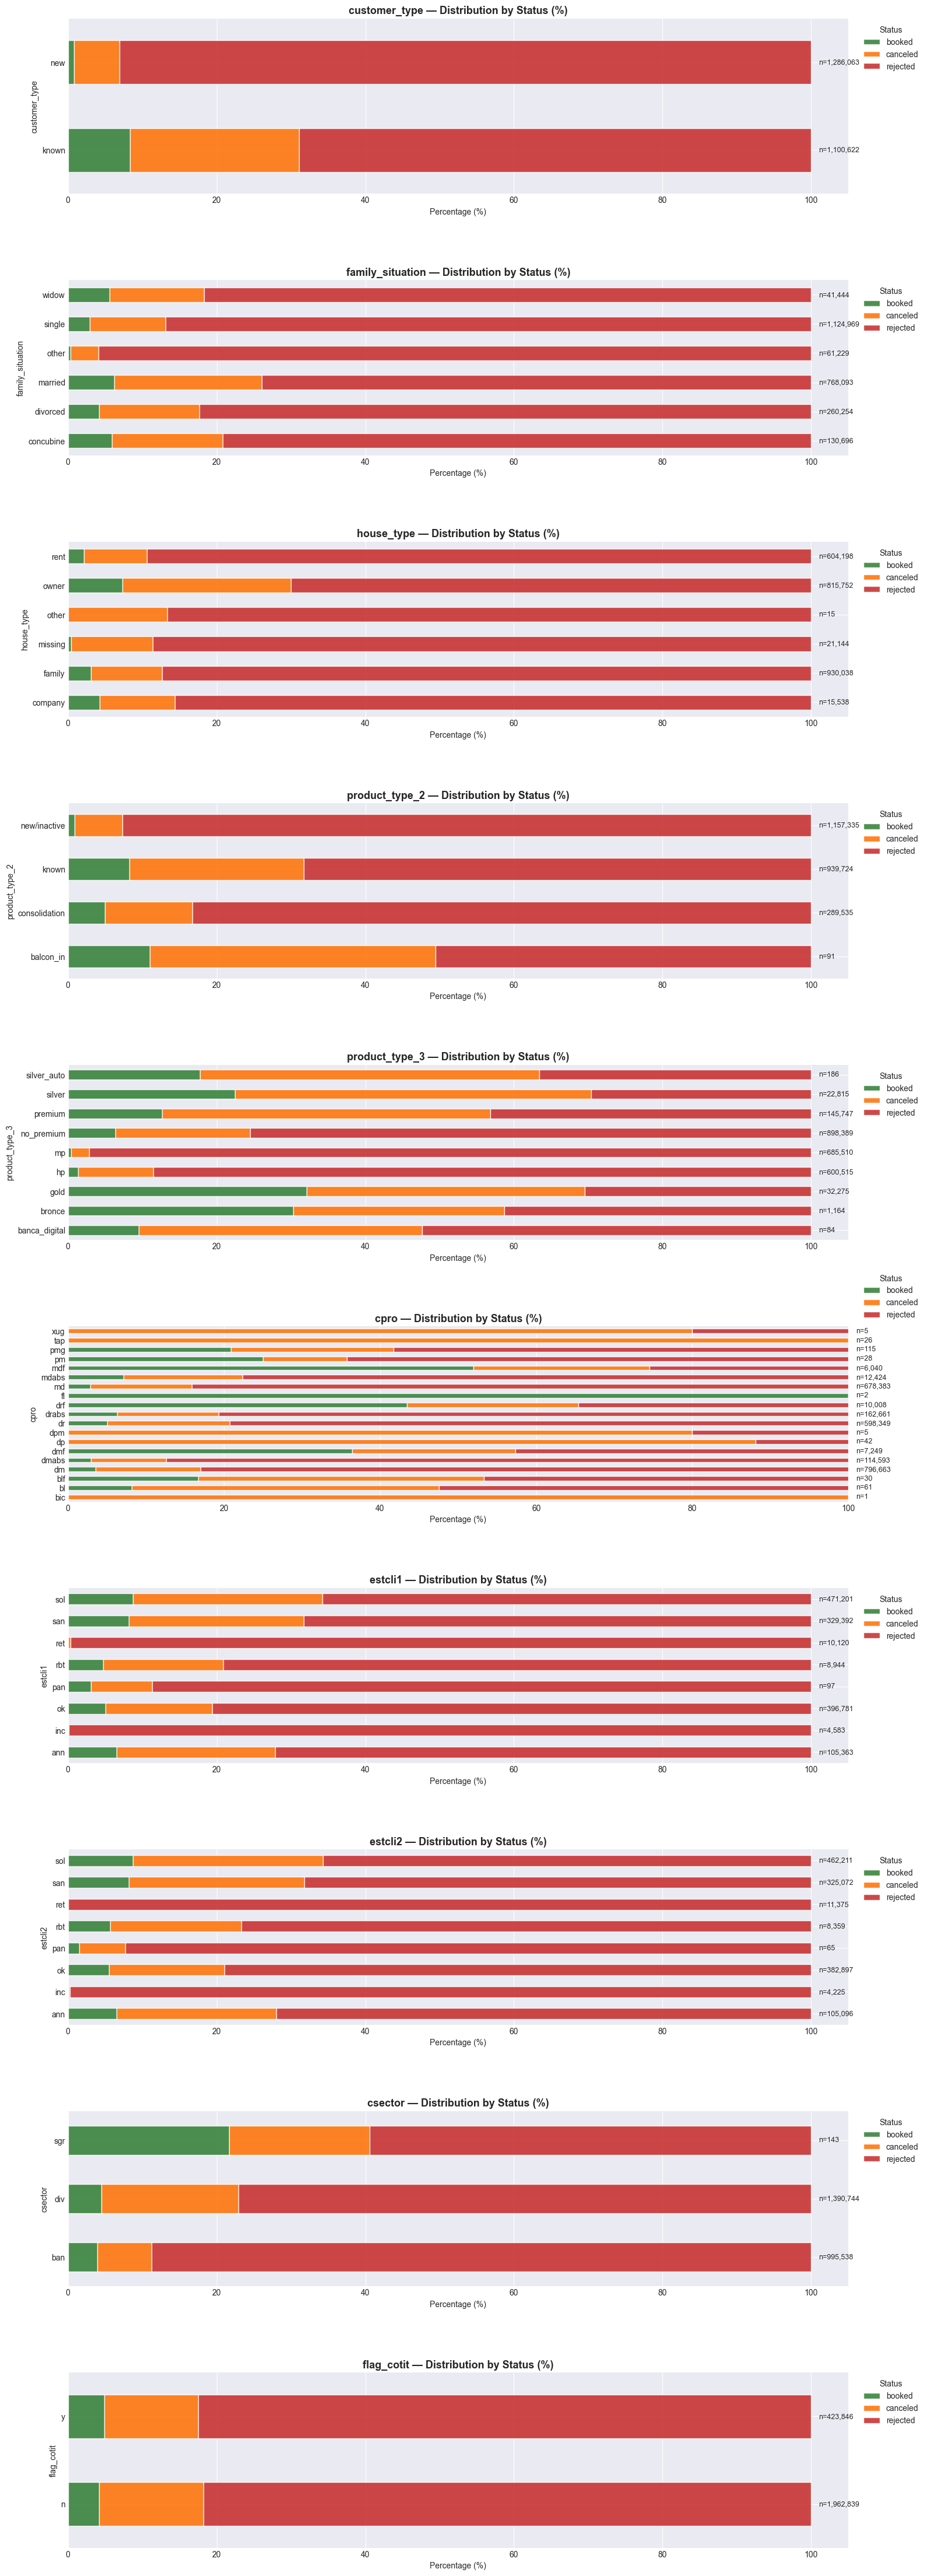

In [53]:
# Categorical variables to analyze (exclude high-cardinality and target/id columns)
cat_analysis = [
    c for c in cat_cols
    if c not in ['reject_reason', 'status_name', 'codrama', 'cmat', 'csp']
]

n_cats = len(cat_analysis)
fig, axes = plt.subplots(n_cats, 1, figsize=(16, 4.5 * n_cats))
if n_cats == 1:
    axes = [axes]

for idx, col in enumerate(cat_analysis):
    ct = pd.crosstab(df_demand[col], df_demand['status_name'], normalize='index') * 100
    # Reorder columns
    ct = ct[[c for c in ['booked', 'canceled', 'rejected'] if c in ct.columns]]
    ct_colors = [palette.get(c, '#999') for c in ct.columns]

    ct.plot(kind='barh', stacked=True, ax=axes[idx],
            color=ct_colors, alpha=0.85, edgecolor='white')
    axes[idx].set_title(f'{col} — Distribution by Status (%)', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Percentage (%)')
    axes[idx].legend(title='Status', bbox_to_anchor=(1.01, 1))

    # Annotate with total counts
    counts = df_demand[col].value_counts()
    for i, label in enumerate(ct.index):
        if label in counts.index:
            axes[idx].text(101, i, f'n={counts[label]:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 8. High-Cardinality Categoricals (Top 15)

## 9. Numerical Variable Distributions

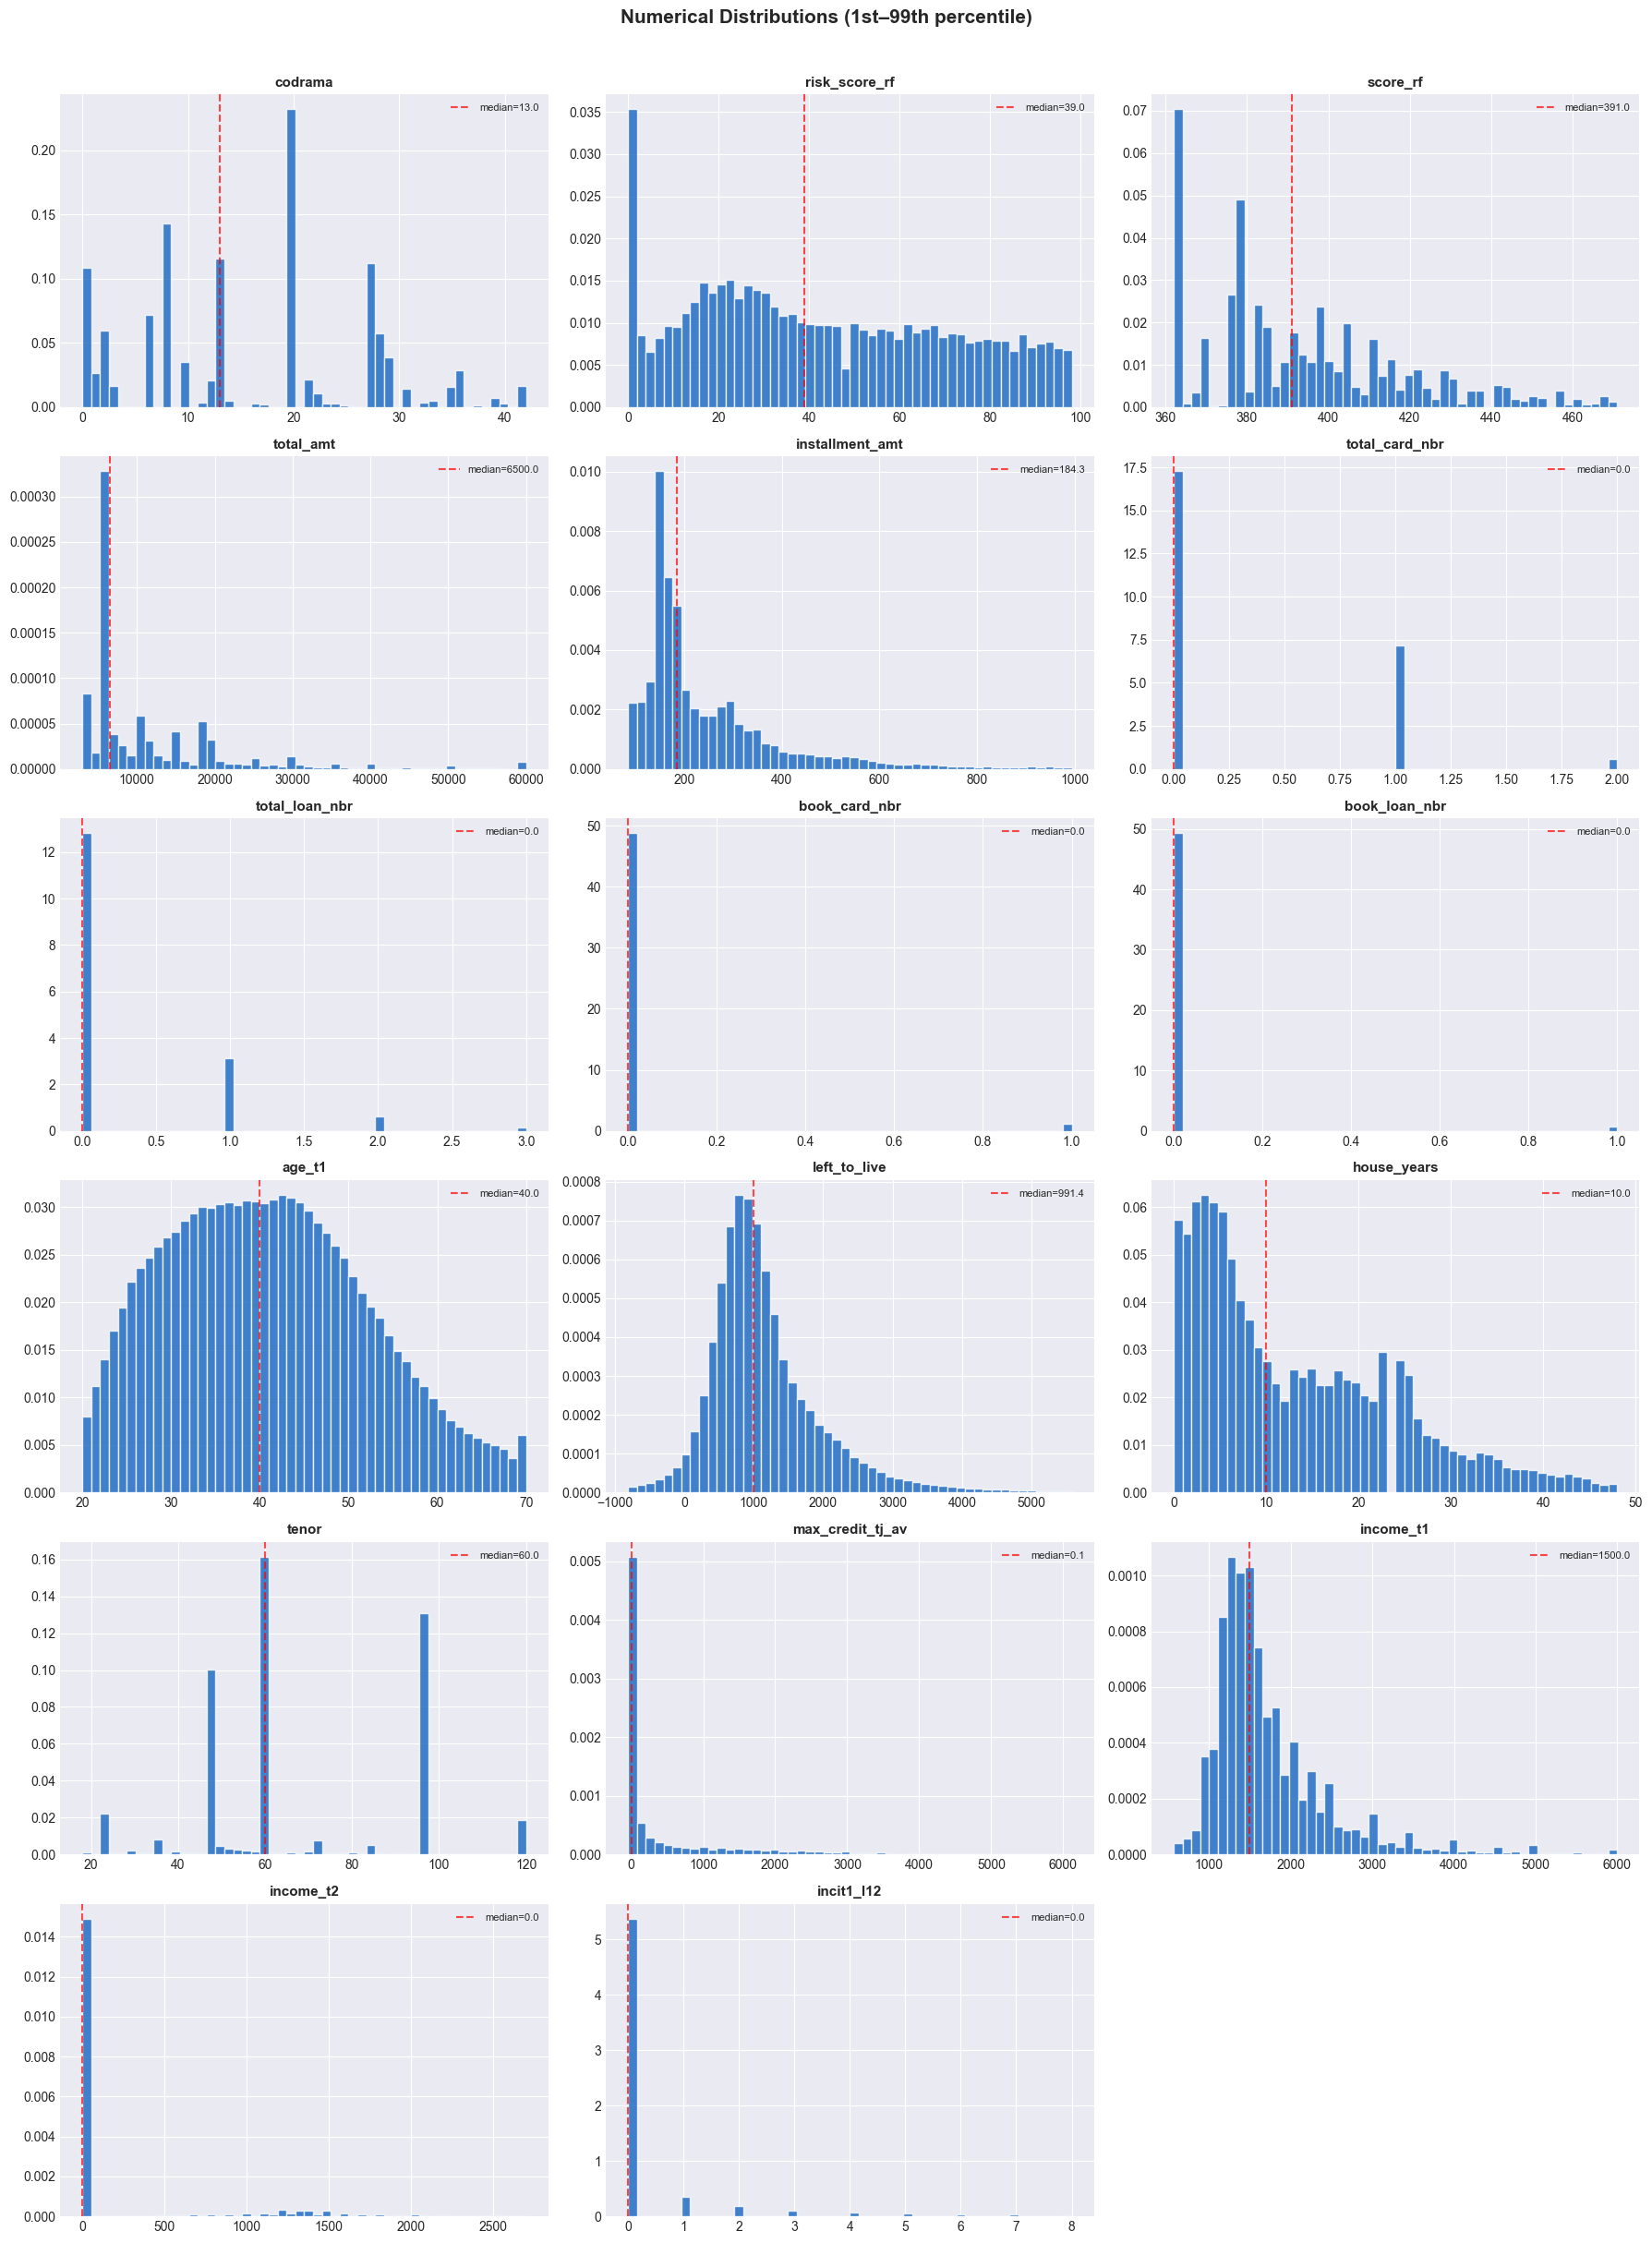

In [54]:
plot_nums = [c for c in num_cols if c not in ['basel_bad']]

ncols = 3
nrows = (len(plot_nums) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for idx, col in enumerate(plot_nums):
    data = df_demand[col].dropna()
    low, high = data.quantile(0.01), data.quantile(0.99)
    data_clip = data[(data >= low) & (data <= high)]

    axes[idx].hist(data_clip, bins=50, color='#1565C0', edgecolor='white', alpha=0.8, density=True)
    axes[idx].axvline(data.median(), color='red', linestyle='--', alpha=0.7, label=f'median={data.median():.1f}')
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].legend(fontsize=8)

for idx in range(len(plot_nums), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Numerical Distributions (1st–99th percentile)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 10. Key Numerical Features by Status

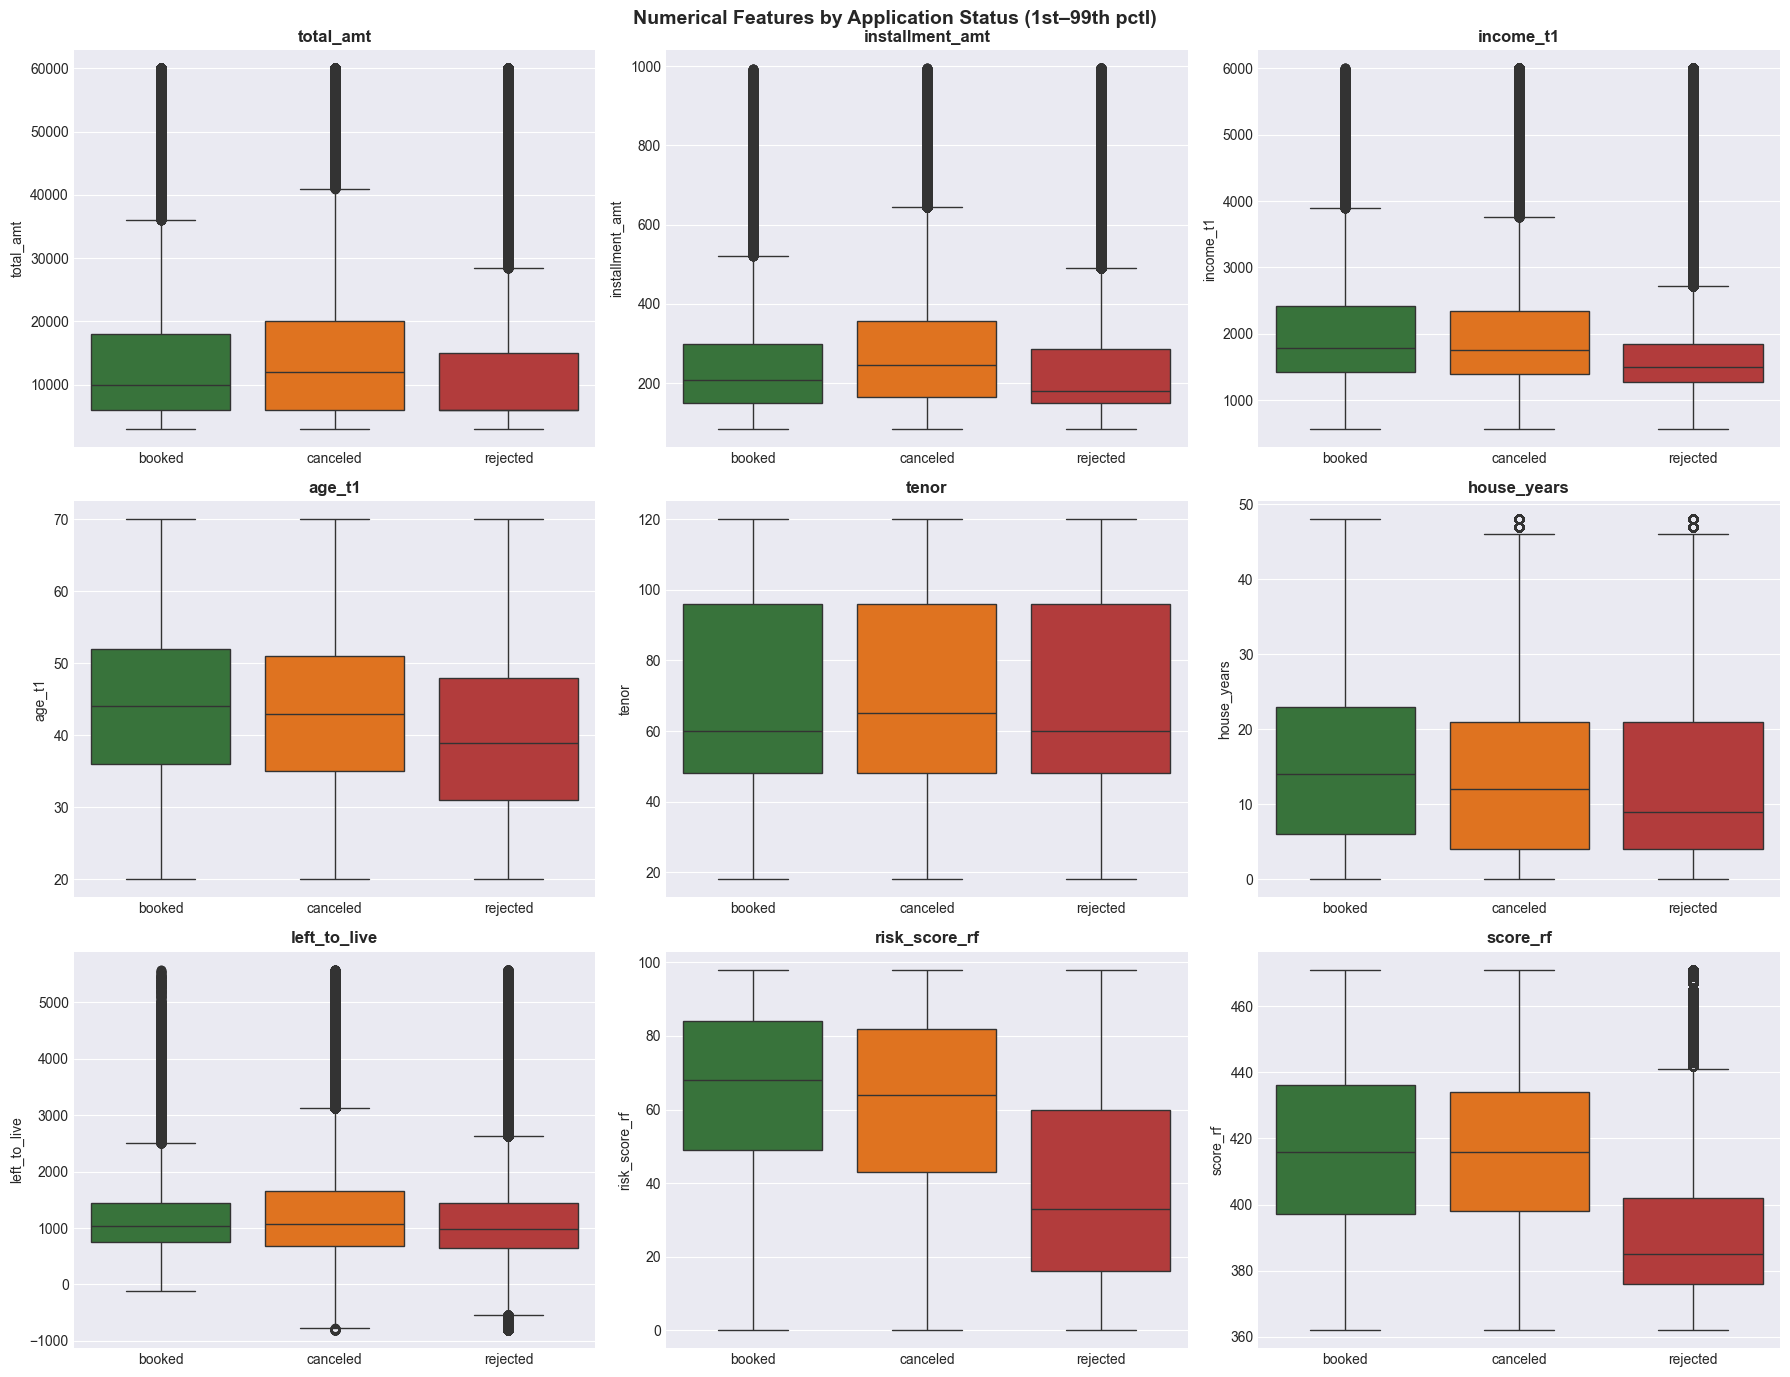

In [55]:
key_nums = ['total_amt', 'installment_amt', 'income_t1', 'age_t1',
            'tenor', 'house_years', 'left_to_live', 'risk_score_rf', 'score_rf']
key_nums = [c for c in key_nums if c in df_demand.columns]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(key_nums):
    data = df_demand[[col, 'status_name']].dropna()
    low, high = data[col].quantile(0.01), data[col].quantile(0.99)
    data = data[(data[col] >= low) & (data[col] <= high)]

    order = [s for s in ['booked', 'canceled', 'rejected'] if s in data['status_name'].unique()]
    box_palette = [palette.get(s, '#999') for s in order]

    sns.boxplot(data=data, x='status_name', y=col, ax=axes[idx],
                order=order, palette=box_palette)
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')

for idx in range(len(key_nums), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Numerical Features by Application Status (1st–99th pctl)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Scoring Variables Deep Dive

Combined score = average percentile rank of `risk_score_rf` and `score_rf` (scale-free; higher = safer).

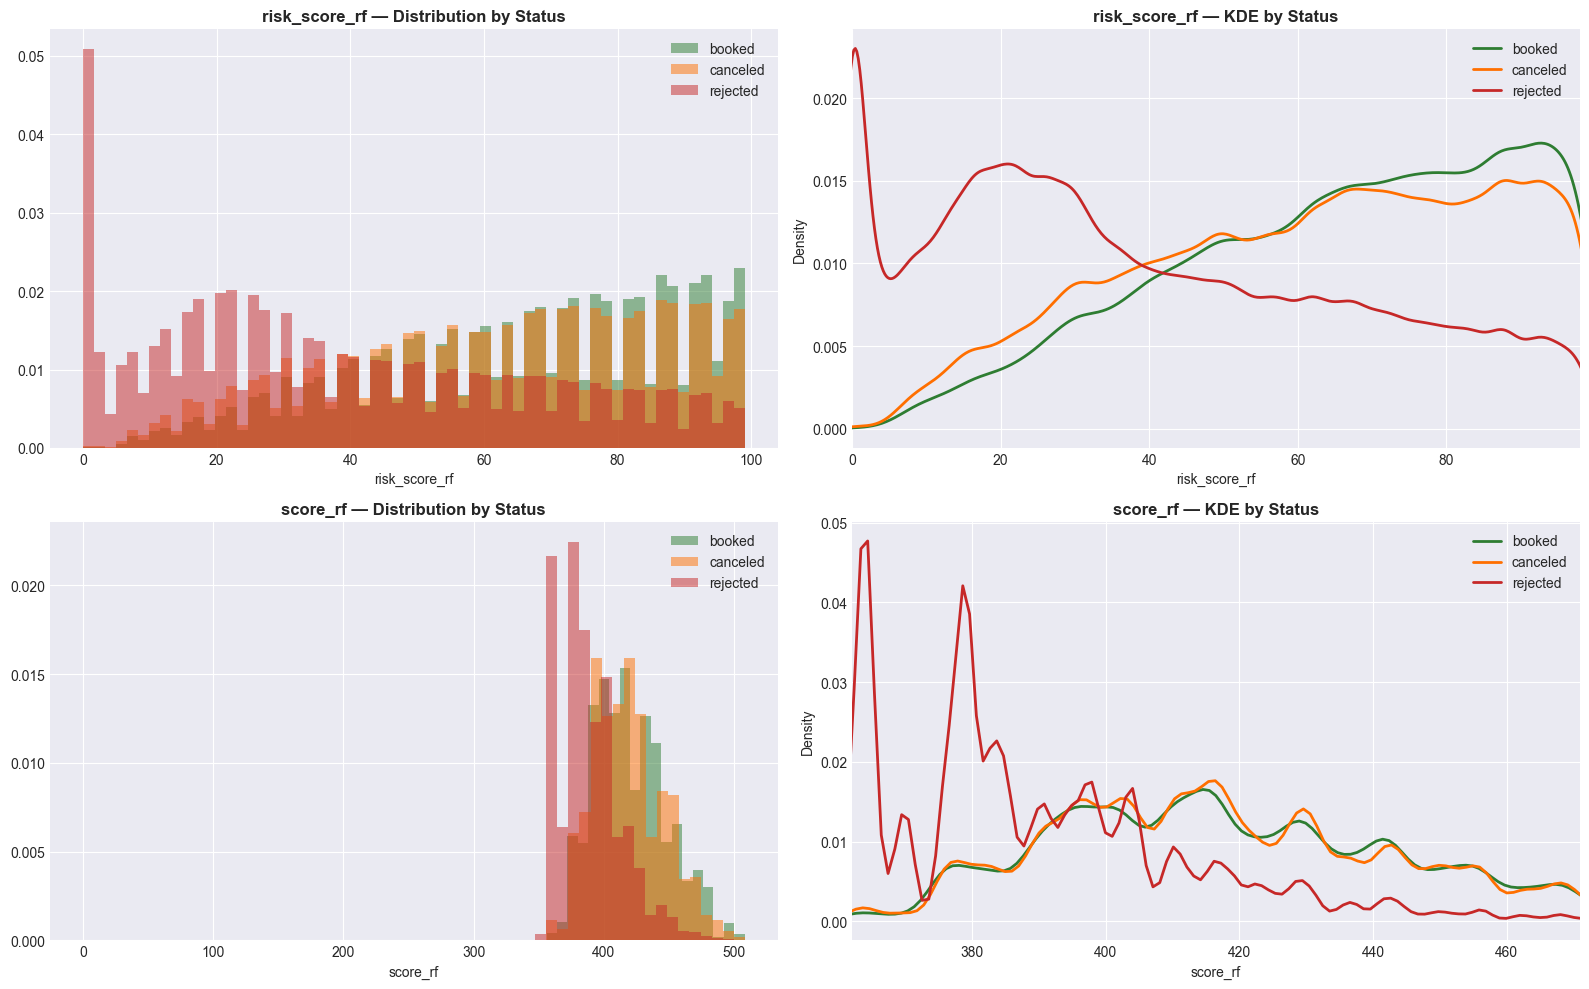


risk_score_rf by status:
                  count   mean    std   min    25%    50%    75%    max
status_name                                                            
booked       102086.000 65.600 22.760 0.000 49.000 68.000 85.000 99.000
canceled     327291.000 61.940 23.950 0.000 44.000 65.000 82.000 99.000
rejected    1951277.000 38.690 27.750 0.000 16.000 33.000 60.000 99.000

score_rf by status:
                  count    mean    std    min     25%     50%     75%     max
status_name                                                                  
booked       102113.000 419.730 28.370 28.000 398.000 416.000 441.000 508.000
canceled     329060.000 418.590 27.120  0.980 398.000 416.000 437.000 508.000
rejected    1955495.000 389.800 23.630  0.000 376.000 385.000 402.000 508.000


In [56]:
score_cols = ['risk_score_rf', 'score_rf']
plot_col = 'combined_score'

# Scale-free blend: average percentile rank of each score (higher = safer, same sign as ROC -col)
df_plot = df_demand.assign(
    combined_score=sum(
        df_demand[c].rank(pct=True, method='average') for c in score_cols
    ) / len(score_cols)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for status in ['booked', 'canceled', 'rejected']:
    subset = df_plot.loc[df_plot['status_name'] == status, plot_col].dropna()
    axes[0].hist(subset, bins=60, alpha=0.5, label=status,
                 color=palette[status], density=True)
axes[0].set_title(f'{plot_col} — Distribution by Status', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlabel(f'mean rank pct of {", ".join(score_cols)}')

for status in ['booked', 'canceled', 'rejected']:
    subset = df_plot.loc[df_plot['status_name'] == status, plot_col].dropna()
    subset.plot.kde(ax=axes[1], label=status, color=palette[status], linewidth=2)
axes[1].set_title(f'{plot_col} — KDE by Status', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].set_xlabel(plot_col)
axes[1].set_xlim(df_plot[plot_col].quantile(0.01), df_plot[plot_col].quantile(0.99))

plt.tight_layout()
plt.show()

print(f"\n{plot_col} by status:")
print(df_plot.groupby('status_name')[plot_col].describe().round(3))


## 12. Bad Rate Analysis (Booked Applications Only)

`basel_bad` is the target variable representing default/bad outcomes. It only applies to booked applications.

**Maturity constraint:** `basel_bad` requires 12 months on book to mature. Applications from 2025-02 onward do not yet have observed outcomes, so we restrict all target-related analyses to `mis_date <= 2025-01`.

In [57]:
# Filter to booked applications with matured outcomes only
# basel_bad needs 12 months on book — data from 2025-02 onward is not yet mature
df_booked = df_demand[
    (df_demand['status_name'] == 'booked') &
    (df_demand['mis_date'] <= '2025-01-01')
].copy()
print(f"Booked applications (matured): {len(df_booked):,}")
print(f"Bad rate (overall): {df_booked['basel_bad'].mean() * 100:.2f}%")
print(f"Bad count: {df_booked['basel_bad'].sum():,.0f} / {df_booked['basel_bad'].notna().sum():,}")

Booked applications (matured): 67,670
Bad rate (overall): 3.81%
Bad count: 2,546 / 66,891


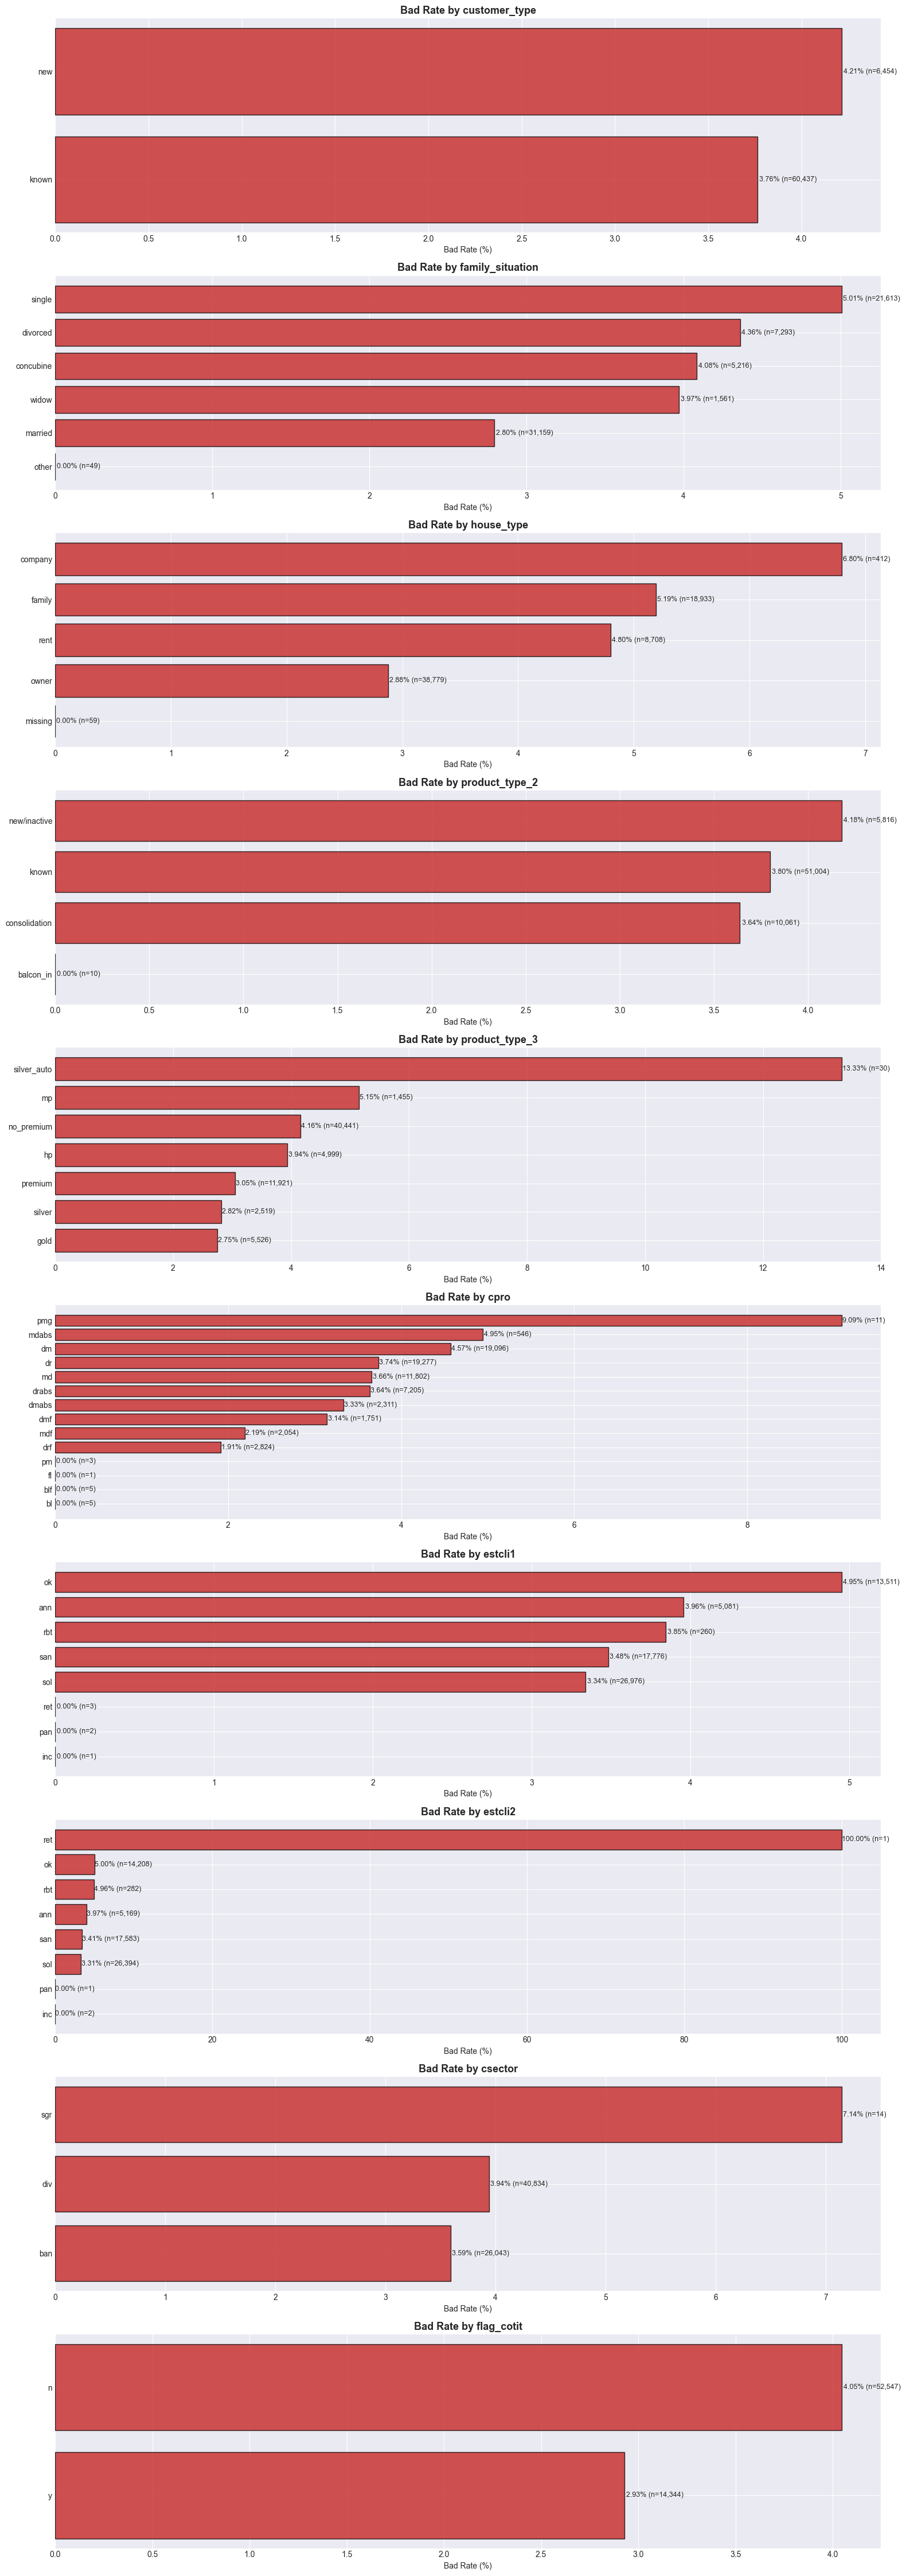

In [58]:
# Bad rate by categorical features
bad_cat_cols = [
    c for c in cat_cols
    if c not in ['status_name', 'reject_reason', 'codrama', 'cmat', 'csp']
    and df_booked[c].nunique() <= 20
]

fig, axes = plt.subplots(len(bad_cat_cols), 1, figsize=(16, 4.5 * len(bad_cat_cols)))
if len(bad_cat_cols) == 1:
    axes = [axes]

for idx, col in enumerate(bad_cat_cols):
    group = df_booked.groupby(col)['basel_bad'].agg(['mean', 'count']).reset_index()
    group.columns = [col, 'bad_rate', 'count']
    group['bad_rate'] *= 100
    group = group.sort_values('bad_rate', ascending=True)

    bars = axes[idx].barh(group[col].astype(str), group['bad_rate'],
                          color='#C62828', edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'Bad Rate by {col}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Bad Rate (%)')

    for i, (rate, cnt) in enumerate(zip(group['bad_rate'], group['count'])):
        axes[idx].text(rate + 0.01, i, f'{rate:.2f}% (n={cnt:,})', va='center', fontsize=9)

plt.tight_layout()
plt.show()


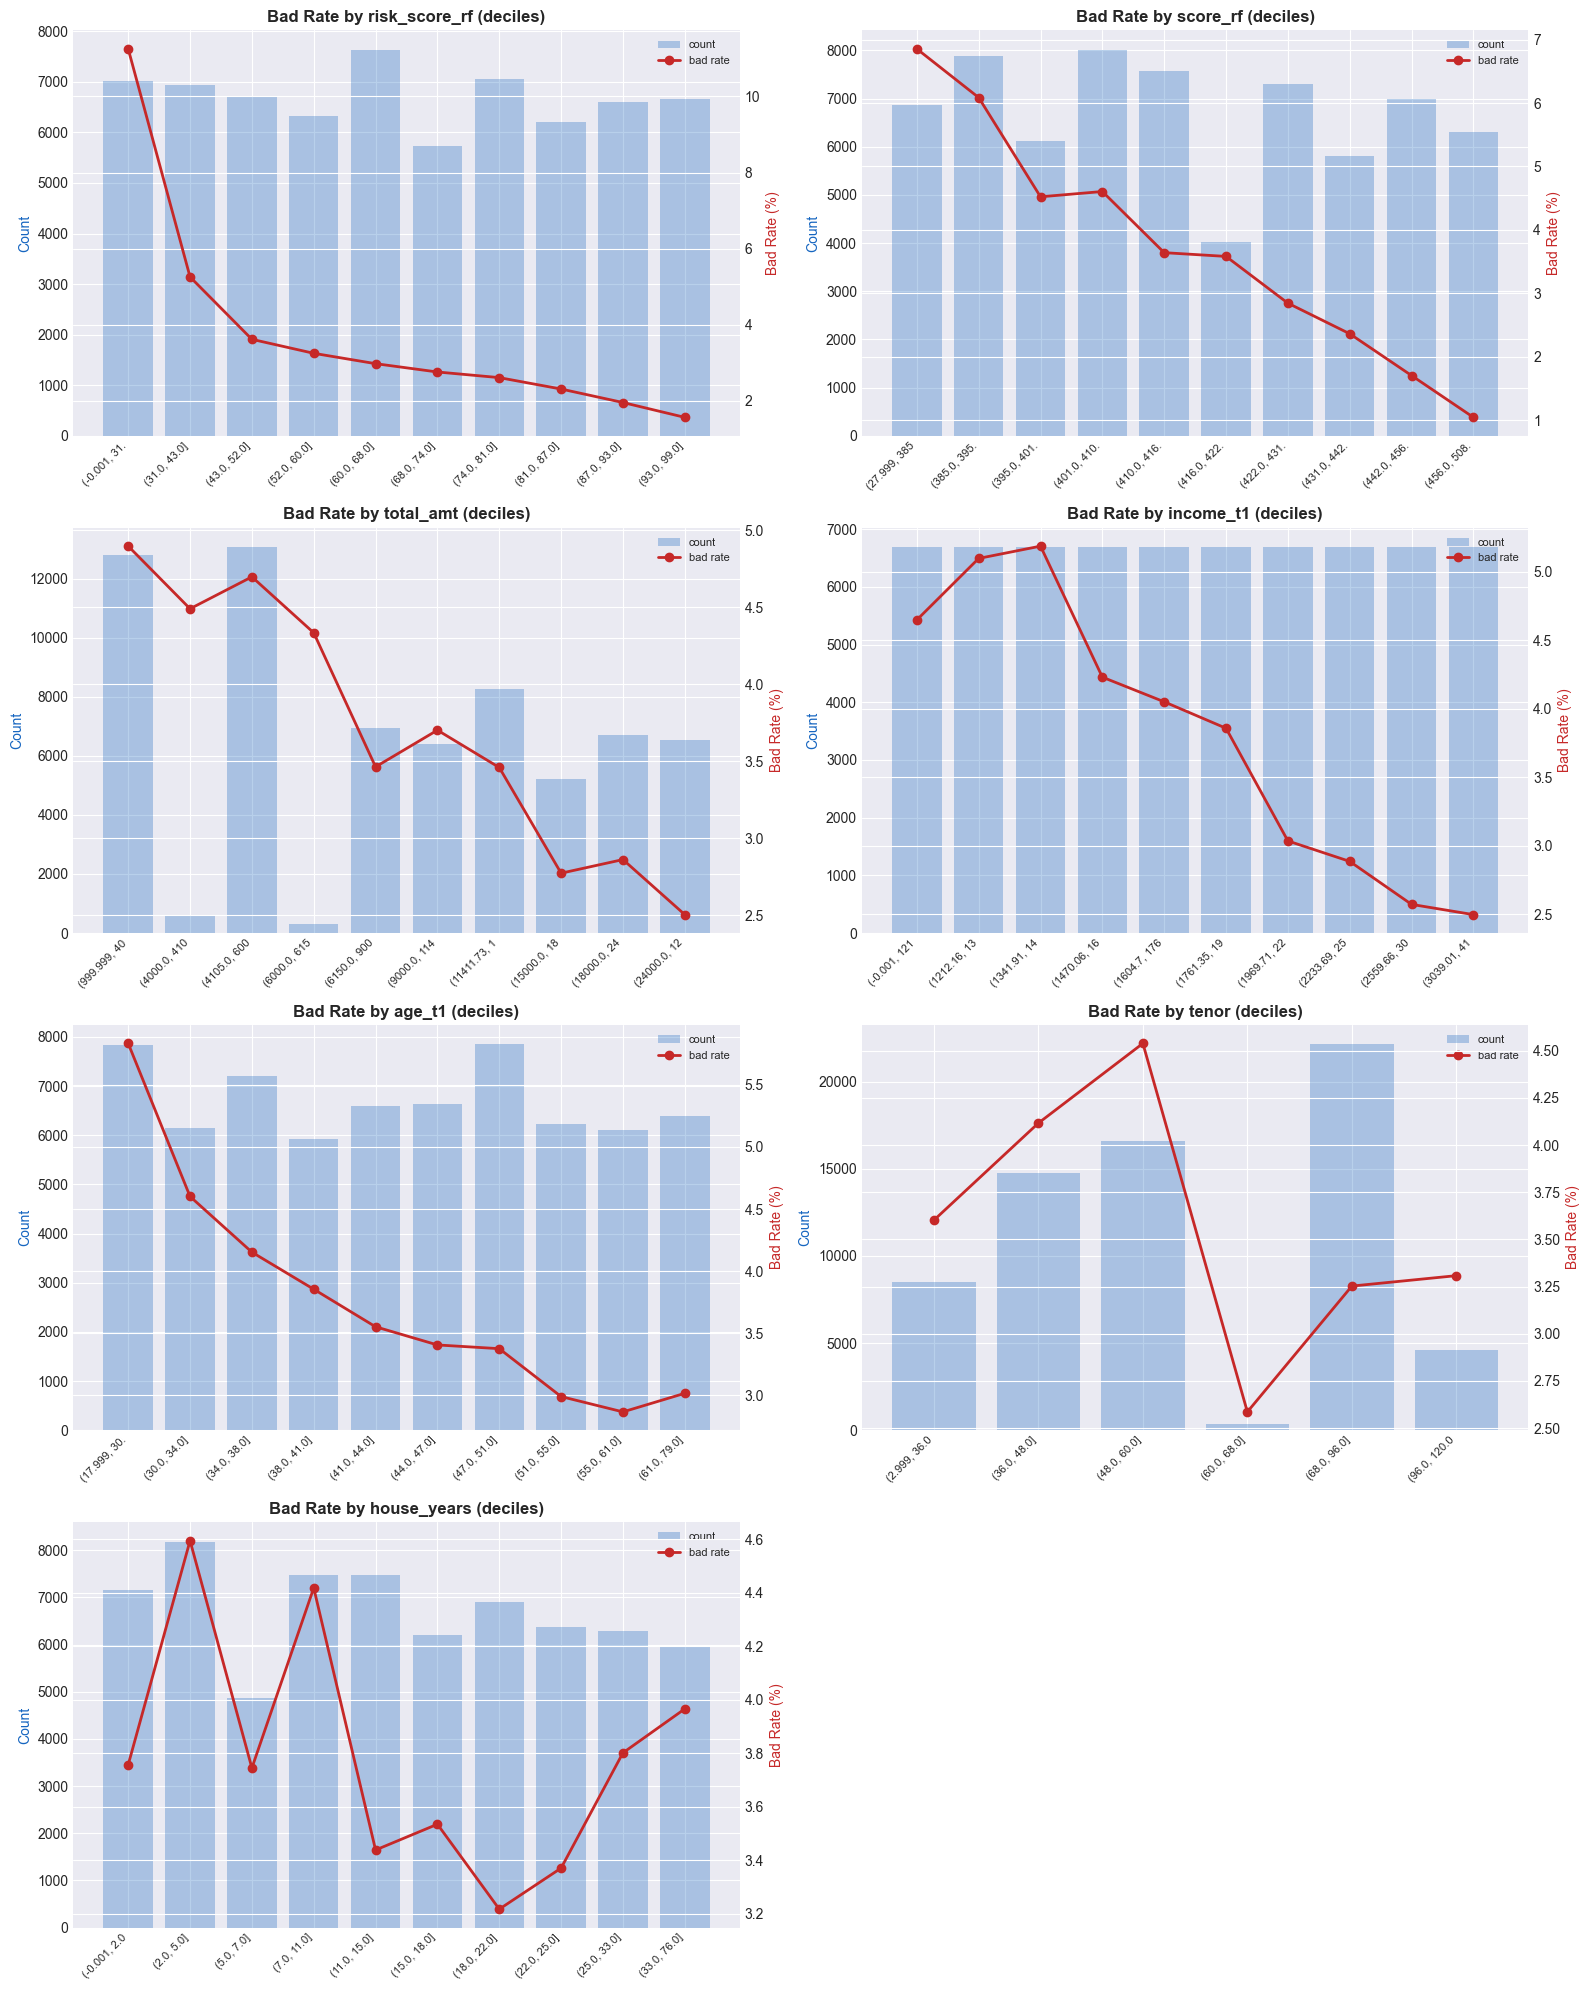

In [59]:
# Bad rate by binned numerical features
bin_cols = ['risk_score_rf', 'score_rf', 'total_amt', 'income_t1',
            'age_t1', 'tenor', 'house_years']
bin_cols = [c for c in bin_cols if c in df_booked.columns]

ncols_grid = 2
nrows_grid = (len(bin_cols) + ncols_grid - 1) // ncols_grid
fig, axes = plt.subplots(nrows_grid, ncols_grid, figsize=(16, 5 * nrows_grid))
axes = axes.flatten()

for idx, col in enumerate(bin_cols):
    data = df_booked[[col, 'basel_bad']].dropna()
    # Create decile bins
    try:
        data['bin'] = pd.qcut(data[col], q=10, duplicates='drop')
    except ValueError:
        data['bin'] = pd.cut(data[col], bins=10)
    group = data.groupby('bin', observed=True)['basel_bad'].agg(['mean', 'count']).reset_index()
    group['mean'] *= 100

    ax2 = axes[idx].twinx()
    axes[idx].bar(range(len(group)), group['count'], color='#1565C0', alpha=0.3, label='count')
    ax2.plot(range(len(group)), group['mean'], color='#C62828', marker='o', linewidth=2, label='bad rate')

    axes[idx].set_title(f'Bad Rate by {col} (deciles)', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(range(len(group)))
    axes[idx].set_xticklabels([str(x)[:12] for x in group['bin']], rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Count', color='#1565C0')
    ax2.set_ylabel('Bad Rate (%)', color='#C62828')

    lines1, labels1 = axes[idx].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[idx].legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

for idx in range(len(bin_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


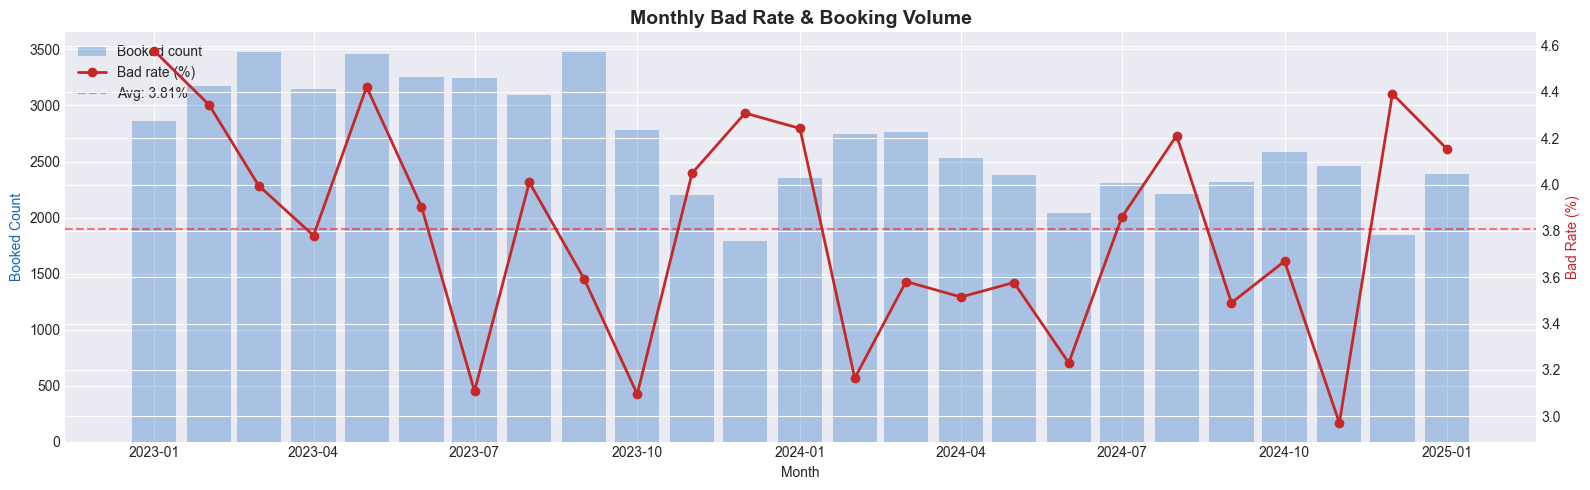

In [60]:
# Bad rate over time
monthly_bad = (
    df_booked
    .groupby(pd.Grouper(key='mis_date', freq='MS'))['basel_bad']
    .agg(['mean', 'count'])
    .reset_index()
)
monthly_bad['mean'] *= 100

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.bar(monthly_bad['mis_date'], monthly_bad['count'], width=25,
        color='#1565C0', alpha=0.3, label='Booked count')
ax2.plot(monthly_bad['mis_date'], monthly_bad['mean'], color='#C62828',
         marker='o', linewidth=2, label='Bad rate (%)')
ax2.axhline(y=monthly_bad['mean'].mean(), color='red', linestyle='--', alpha=0.5,
            label=f'Avg: {monthly_bad["mean"].mean():.2f}%')

ax1.set_xlabel('Month')
ax1.set_ylabel('Booked Count', color='#1565C0')
ax2.set_ylabel('Bad Rate (%)', color='#C62828')
ax1.set_title('Monthly Bad Rate & Booking Volume', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


## 13. Correlation Analysis

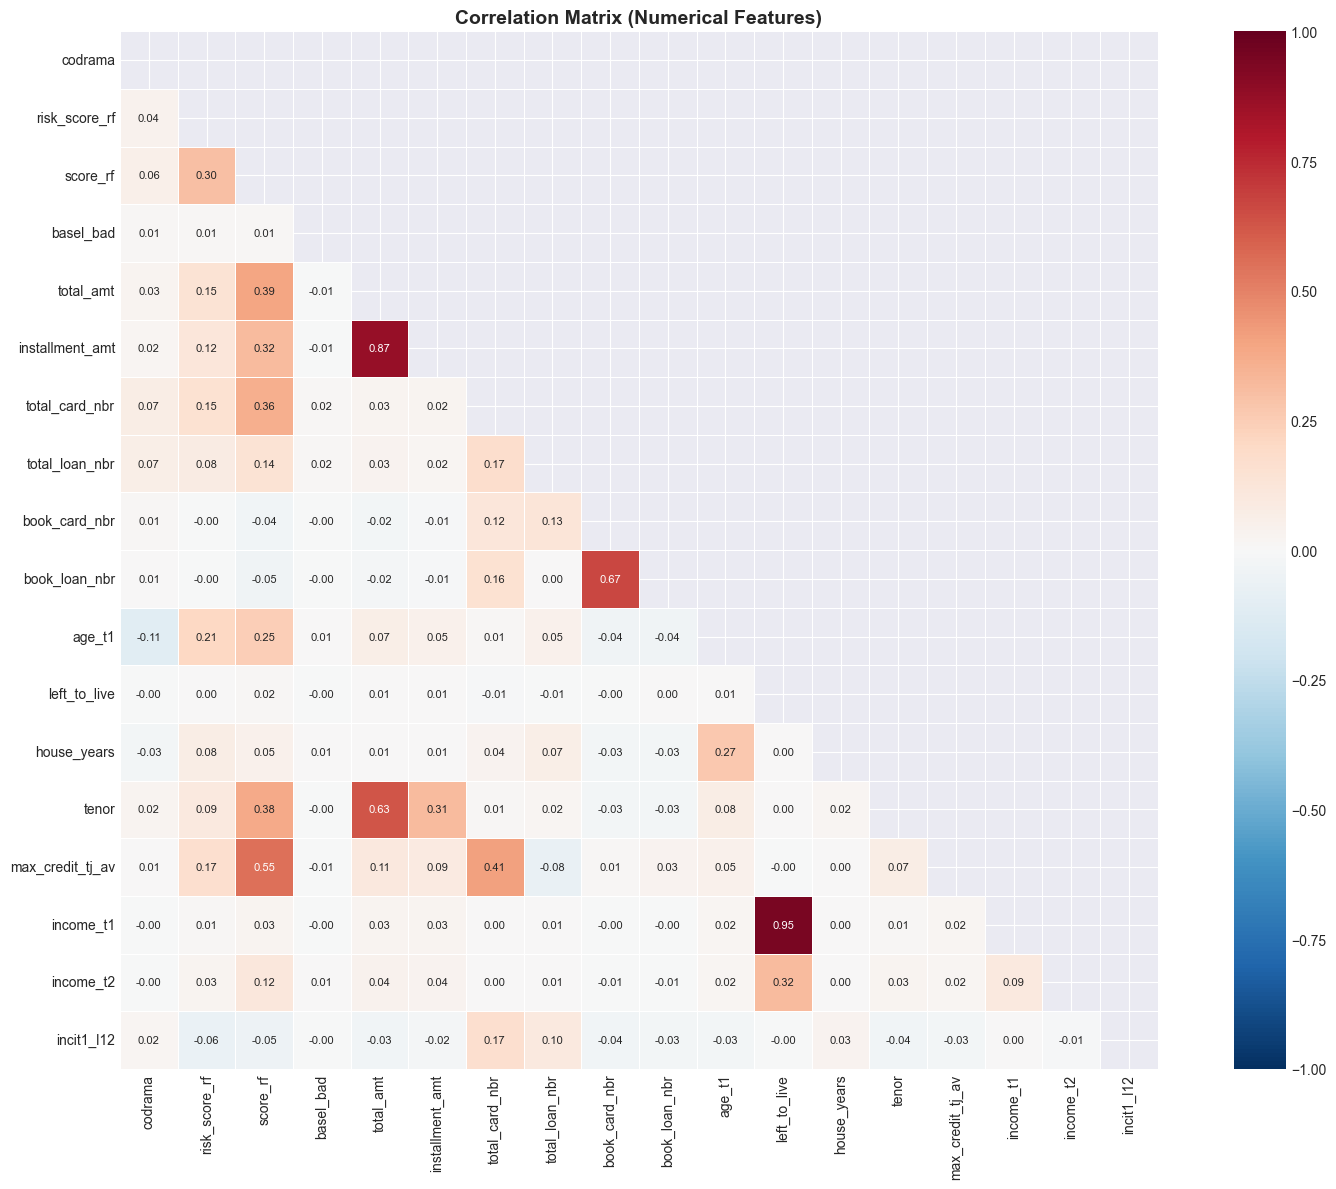


Top 15 correlations:
            var1            var2  corr  abs_corr
       income_t1    left_to_live 0.950     0.950
 installment_amt       total_amt 0.874     0.874
   book_loan_nbr   book_card_nbr 0.669     0.669
           tenor       total_amt 0.630     0.630
max_credit_tj_av        score_rf 0.554     0.554
max_credit_tj_av  total_card_nbr 0.408     0.408
       total_amt        score_rf 0.395     0.395
           tenor        score_rf 0.375     0.375
  total_card_nbr        score_rf 0.364     0.364
 installment_amt        score_rf 0.319     0.319
       income_t2    left_to_live 0.318     0.318
           tenor installment_amt 0.314     0.314
        score_rf   risk_score_rf 0.299     0.299
     house_years          age_t1 0.272     0.272
          age_t1        score_rf 0.246     0.246


In [61]:
corr_cols = [c for c in num_cols if df_demand[c].notna().mean() > 0.5]
corr_matrix = df_demand[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top absolute correlations (excluding self)
corr_pairs = (
    corr_matrix.where(~mask)
    .stack()
    .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']
corr_pairs['abs_corr'] = corr_pairs['corr'].abs()
print("\nTop 15 correlations:")
print(corr_pairs.nlargest(15, 'abs_corr').to_string(index=False))


## 14. Missing Values Analysis

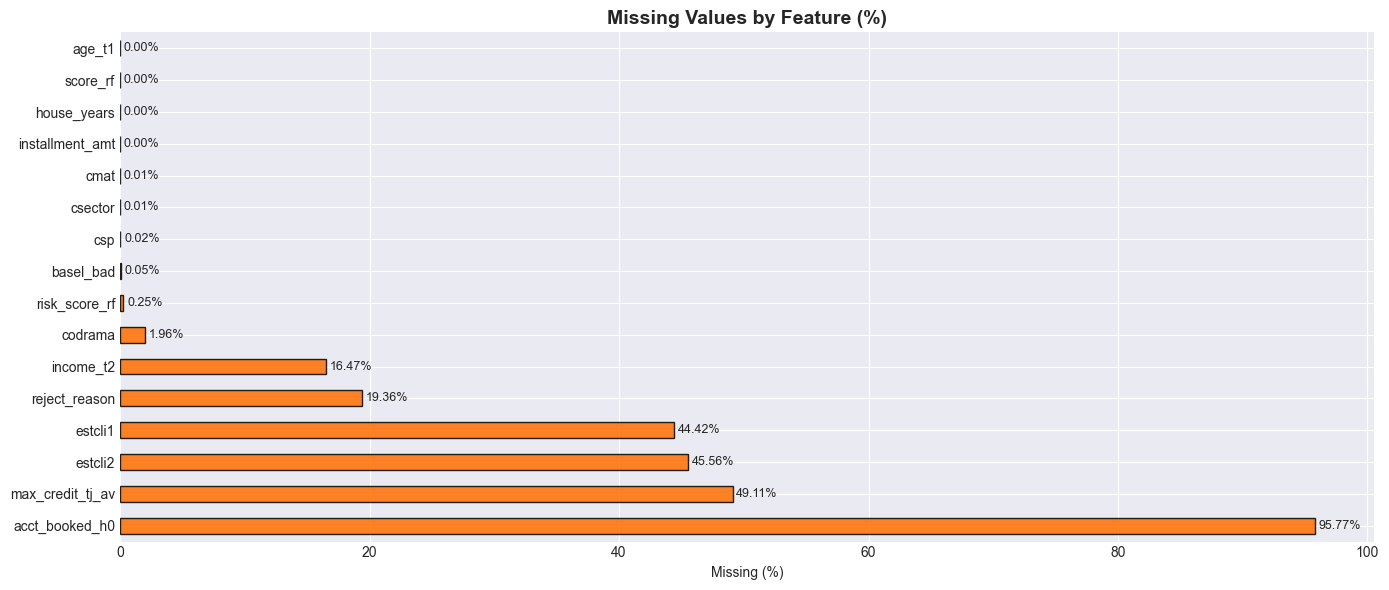

In [62]:
# Missing values overview
miss_pct = (df_demand.isnull().mean() * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

fig, ax = plt.subplots(figsize=(14, 6))
miss_pct.plot(kind='barh', color='#FF6F00', edgecolor='black', alpha=0.85, ax=ax)
ax.set_title('Missing Values by Feature (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing (%)')
for i, v in enumerate(miss_pct.values):
    ax.text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


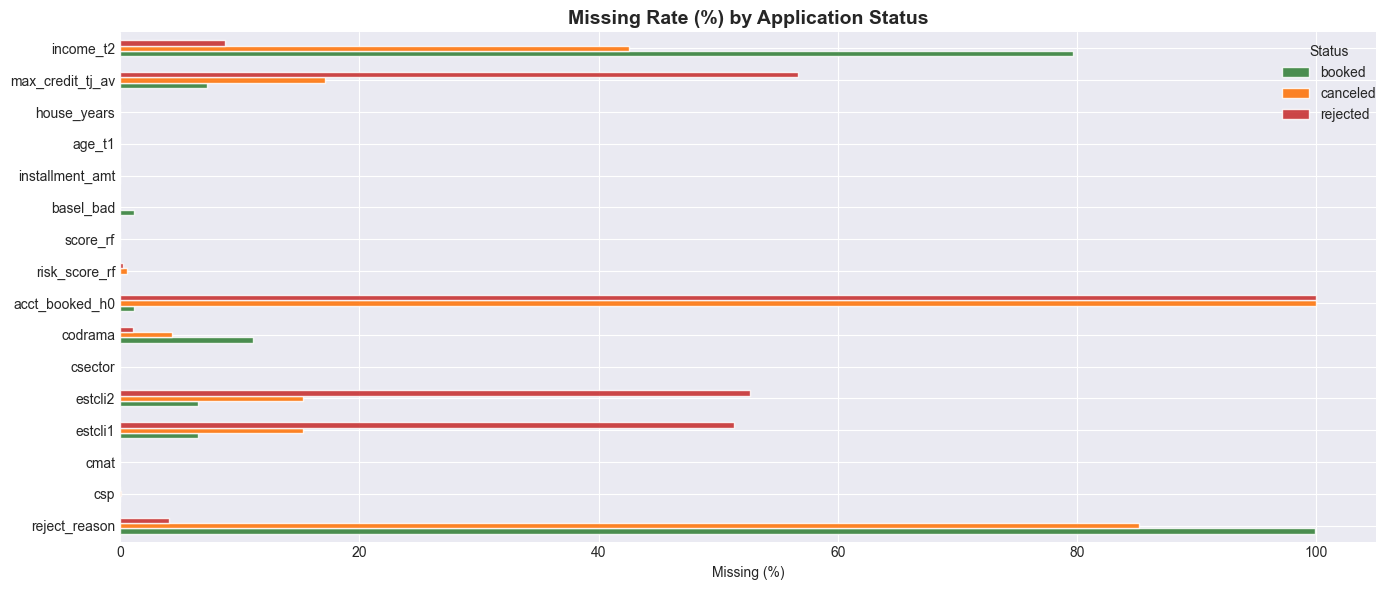

status_name,booked,canceled,rejected
reject_reason,99.930,85.200,4.080
csp,0.010,0.060,0.020
cmat,0.000,0.000,0.010
estcli1,6.520,15.310,51.300
estcli2,6.490,15.330,52.690
csector,0.000,0.000,0.010
codrama,11.130,4.360,1.070
acct_booked_h0,1.140,100.000,100.000
risk_score_rf,0.030,0.540,0.220
score_rf,0.000,0.000,0.000


In [63]:
# Missing rates by status
miss_by_status = (
    df_demand.groupby('status_name')
    .apply(lambda g: g.isnull().mean() * 100, include_groups=False)
)

# Show only columns with any missing values
cols_with_miss = miss_by_status.columns[miss_by_status.max() > 0]
miss_by_status = miss_by_status[cols_with_miss].T.round(2)

fig, ax = plt.subplots(figsize=(14, 6))
miss_by_status.plot(kind='barh', ax=ax,
                    color=[palette.get(c, '#999') for c in miss_by_status.columns],
                    edgecolor='white', alpha=0.85)
ax.set_title('Missing Rate (%) by Application Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing (%)')
ax.legend(title='Status', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

miss_by_status


## 15. Summary Statistics by Status

In [64]:
# Numerical feature means by status
status_summary = df_demand.groupby('status_name')[num_cols].mean().T.round(3)
status_summary['booked_vs_rejected'] = (
    (status_summary.get('booked', 0) - status_summary.get('rejected', 0))
    / status_summary.get('rejected', 1) * 100
).round(1)
status_summary


status_name,booked,canceled,rejected,booked_vs_rejected
codrama,18.884,17.528,15.459,22.200
risk_score_rf,65.601,61.943,38.691,69.600
score_rf,419.726,418.586,389.800,7.700
basel_bad,0.026,0.000,0.000,inf
total_amt,12248.415,15369.975,11299.101,8.400
installment_amt,241.275,302.819,247.624,-2.600
total_card_nbr,0.560,0.580,0.283,97.900
total_loan_nbr,0.568,0.440,0.258,120.200
book_card_nbr,0.011,0.017,0.033,-66.700
book_loan_nbr,0.003,0.004,0.016,-81.200


## 16. Booked Population Profile

Detailed comparison of booked vs non-booked applications and good vs bad within booked.

In [65]:
# Booked vs non-booked profile comparison
df_demand['is_booked'] = (df_demand['status_name'] == 'booked').astype(int)

profile_cols = ['total_amt', 'installment_amt', 'income_t1', 'age_t1',
                'tenor', 'house_years', 'risk_score_rf', 'score_rf',
                'total_card_nbr', 'total_loan_nbr', 'max_credit_tj_av']

profile = df_demand.groupby('is_booked')[profile_cols].agg(['mean', 'median', 'std']).T
profile.columns = ['Not Booked', 'Booked']
profile.index = pd.MultiIndex.from_tuples(profile.index)
print("Booked vs Not Booked — Feature Profile:")
profile.round(2)

Booked vs Not Booked — Feature Profile:


Not Booked    Booked
total_amt        mean     11885.460 12248.420
                 median    6500.000 10000.000
                 std      10289.970  9618.180
installment_amt  mean       255.570   241.270
                 median     183.520   201.350
                 std        186.480   146.000
income_t1        mean      1893.260  2054.370
                 median    1500.000  1790.740
                 std       9091.870  1011.950
age_t1           mean        40.420    44.970
                 median      40.000    45.000
                 std         11.800    11.670
tenor            mean        66.810    68.720
                 median      60.000    60.000
                 std         24.040    26.550
house_years      mean        13.350    15.800
                 median      10.000    14.000
                 std         11.640    11.890
risk_score_rf    mean        42.030    65.600
                 median      38.000    68.000
                 std         28.430    22.760
score_rf         mean       393.950   419.730
                 median     389.000   416.000
                 std         26.190    28.370
total_card_nbr   mean         0.330     0.560
                 median       0.000     1.000
                 std          0.520     0.570
total_loan_nbr   mean         0.280     0.570
                 median       0.000     0.000
                 std          0.630     0.760
max_credit_tj_av mean       517.900   788.270
                 median       0.010     2.630
                 std       1166.520  1356.330

In [66]:
# Clean up helper column
df_demand.drop(columns=['is_booked'], inplace=True)

In [67]:
# Good vs Bad profile within booked accounts (matured only)
df_booked = df_demand[
    (df_demand['status_name'] == 'booked') &
    (df_demand['mis_date'] <= '2025-01-01')
].copy()
df_booked['bad_label'] = df_booked['basel_bad'].map({0: 'Good', 1: 'Bad'})

good_bad_profile = (
    df_booked
    .groupby('bad_label')[profile_cols]
    .agg(['mean', 'median'])
    .T
)
good_bad_profile.index = pd.MultiIndex.from_tuples(good_bad_profile.index)
print("Good vs Bad within Booked — Feature Profile:")
good_bad_profile.round(2)

Good vs Bad within Booked — Feature Profile:


bad_label                     Bad      Good
total_amt        mean   10160.810 12054.300
                 median  6150.000  9000.000
installment_amt  mean     211.880   240.730
                 median   175.800   200.780
income_t1        mean    1826.810  2026.700
                 median  1600.100  1769.460
age_t1           mean      42.420    44.970
                 median    42.000    44.000
tenor            mean      66.020    67.870
                 median    60.000    60.000
house_years      mean      15.590    16.020
                 median    13.000    15.000
risk_score_rf    mean      49.930    65.140
                 median    48.000    68.000
score_rf         mean     405.920   419.220
                 median   403.000   416.000
total_card_nbr   mean       0.580     0.570
                 median     1.000     1.000
total_loan_nbr   mean       0.600     0.610
                 median     0.000     0.000
max_credit_tj_av mean     397.470   730.820
                 median     0.130     1.660

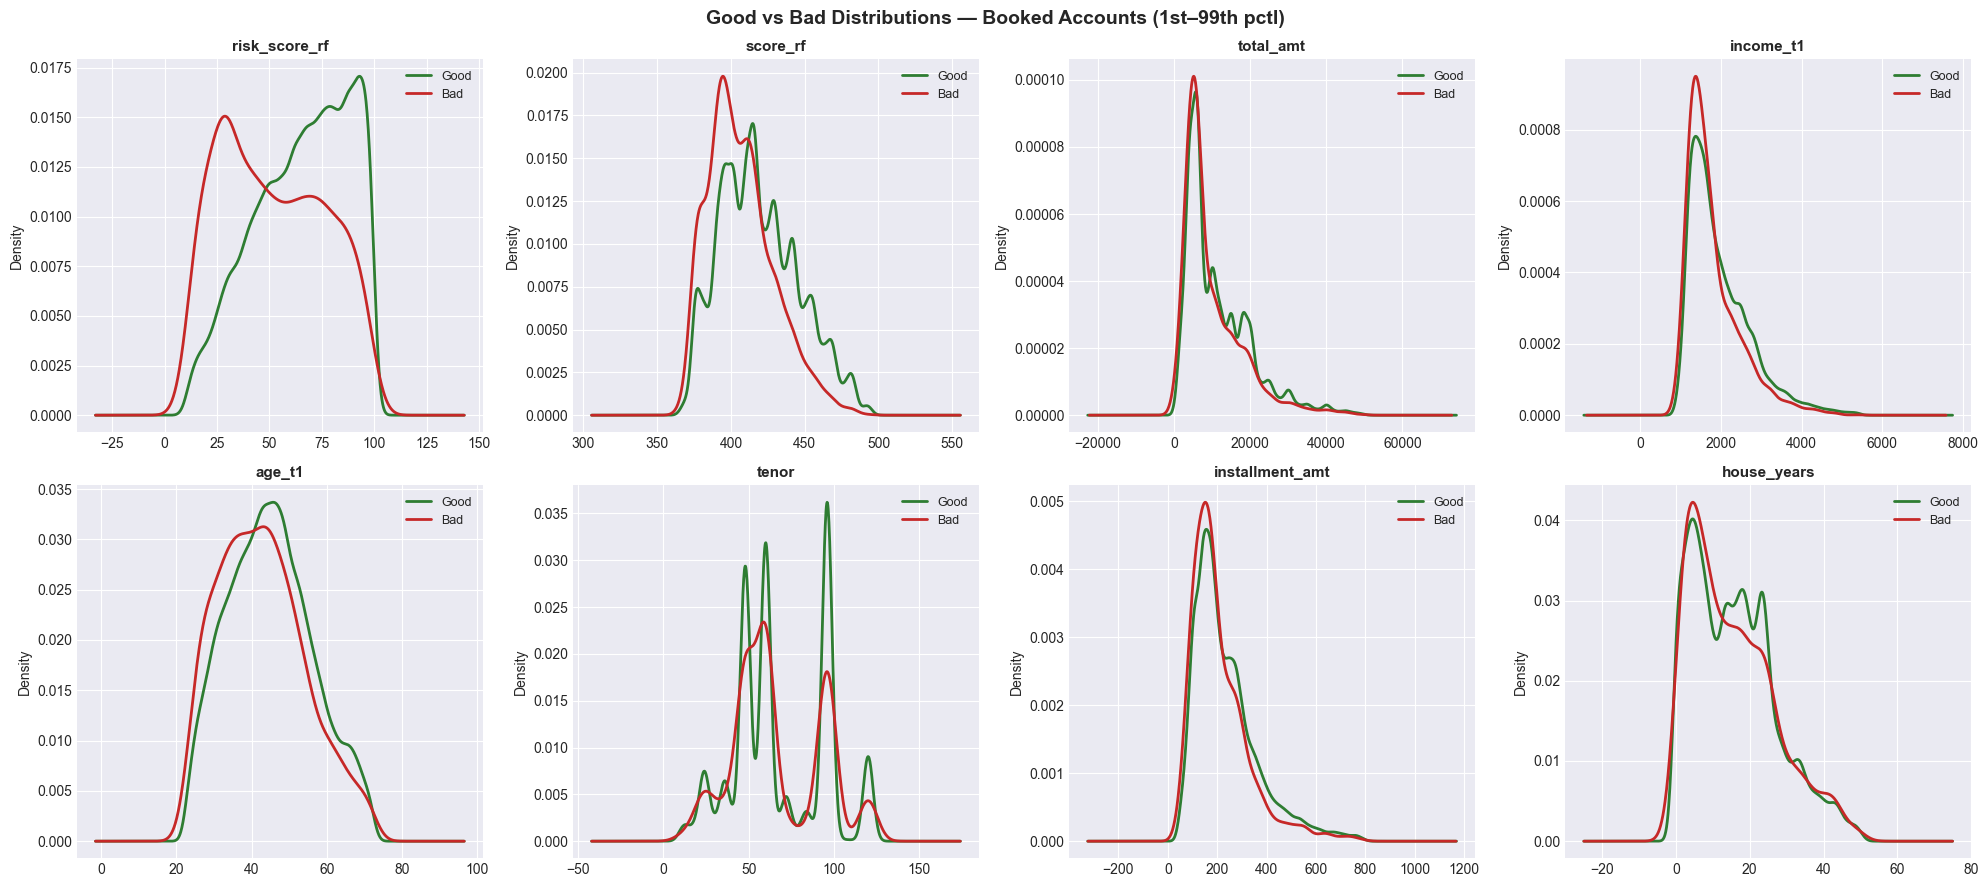

In [68]:
# KDE comparison: Good vs Bad for key features (booked only)
plot_features = ['risk_score_rf', 'score_rf', 'total_amt', 'income_t1',
                 'age_t1', 'tenor', 'installment_amt', 'house_years']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, col in enumerate(plot_features):
    for label, color in [('Good', COLORS['normal']), ('Bad', COLORS['fraud'])]:
        subset = df_booked.loc[df_booked['bad_label'] == label, col].dropna()
        low, high = df_booked[col].dropna().quantile(0.01), df_booked[col].dropna().quantile(0.99)
        subset = subset[(subset >= low) & (subset <= high)]
        if len(subset) > 10:
            subset.plot.kde(ax=axes[idx], label=label, color=color, linewidth=2)
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].legend(fontsize=9)

plt.suptitle('Good vs Bad Distributions — Booked Accounts (1st–99th pctl)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Score Performance on Booked Accounts

ROC-AUC, KS statistic, and Gini coefficient for `risk_score_rf` and `score_rf` as predictors of `basel_bad`.

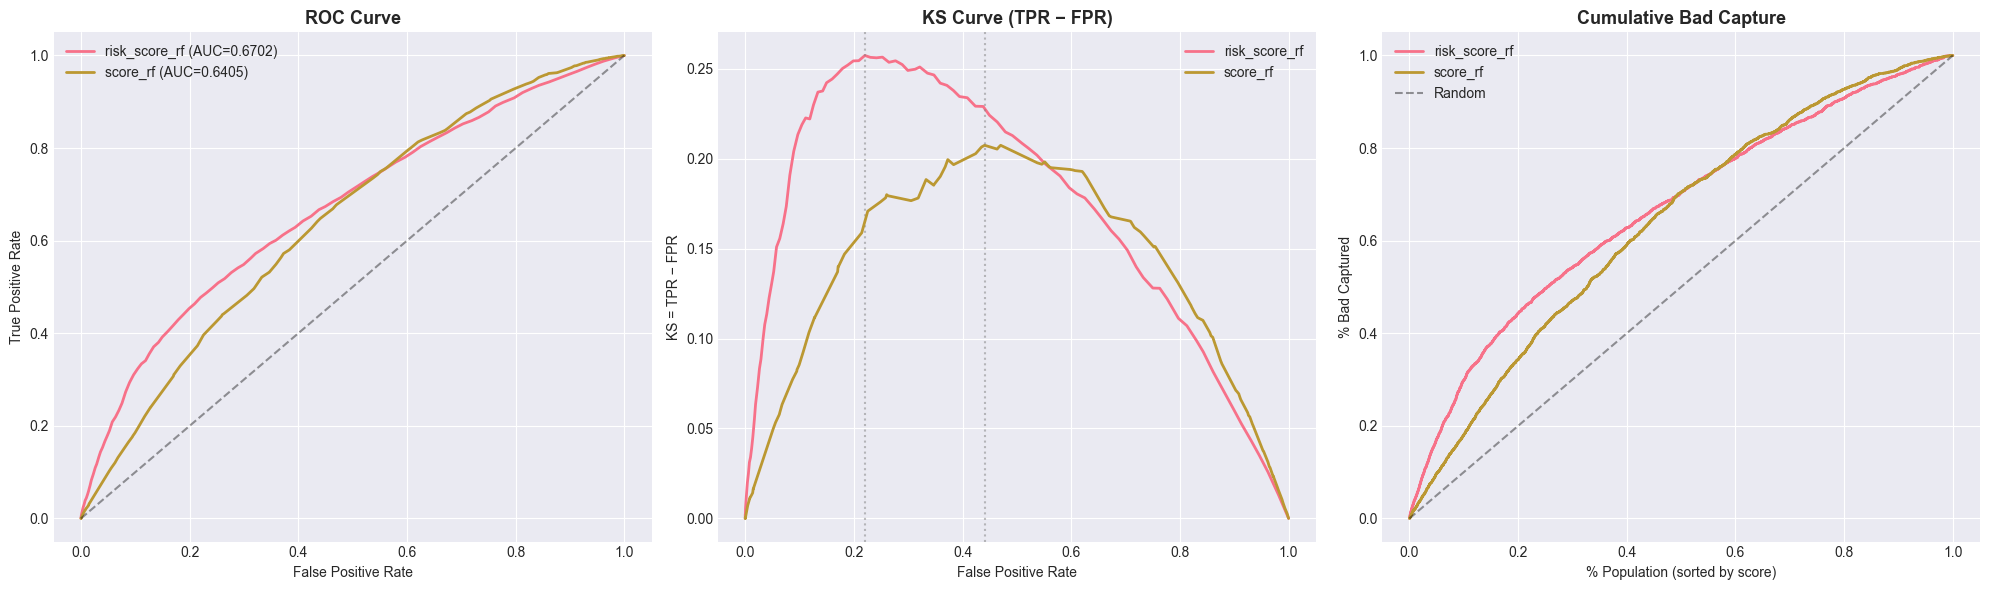

,Score,AUC,KS,Gini,N,Bad Rate
0,risk_score_rf,0.670,0.257,0.340,66866,3.81%
1,score_rf,0.640,0.207,0.281,66890,3.81%


In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

base_cols = ['risk_score_rf', 'score_rf']
eval_base = df_booked[base_cols + ['basel_bad']].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(eval_base[base_cols])

lr = LogisticRegression(max_iter=1000)
lr.fit(X_scaled, eval_base['basel_bad'])
eval_base['combined_logit'] = lr.predict_proba(X_scaled)[:, 1]

print('Logistic blend (standardized inputs → P(basel_bad))')
for col, coef in zip(base_cols, lr.coef_[0]):
    print(f'  {col}: {coef:+.4f}')
print(f'  intercept: {lr.intercept_[0]:+.4f}')

df_booked = df_booked.copy()
df_booked['combined_logit'] = np.nan
df_booked.loc[eval_base.index, 'combined_logit'] = eval_base['combined_logit']

# Higher raw scores = safer; negate for ROC/KS. Combined logit: higher = riskier.
score_vars = [
    ('risk_score_rf', True, True),
    ('score_rf', True, True),
    ('combined_logit', False, False),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
perf_results = []

for col, invert, sort_ascending in score_vars:
    eval_df = eval_base if col == 'combined_logit' else df_booked[[col, 'basel_bad']].dropna()
    y_true = eval_df['basel_bad'].values
    y_score = (-eval_df[col].values) if invert else eval_df[col].values

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{col} (AUC={auc:.4f})')

    axes[1].plot(fpr, tpr - fpr, linewidth=2, label=f'{col}')
    ks_stat = np.max(tpr - fpr)
    ks_idx = np.argmax(tpr - fpr)
    axes[1].axvline(fpr[ks_idx], color='gray', linestyle=':', alpha=0.5)

    gini = 2 * auc - 1
    perf_results.append({
        'Score': col,
        'AUC': round(auc, 4),
        'KS': round(ks_stat, 4),
        'Gini': round(gini, 4),
        'N': len(eval_df),
        'Bad Rate': f"{y_true.mean()*100:.2f}%"
    })

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=10)

axes[1].set_title('KS Curve (TPR − FPR)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('KS = TPR − FPR')
axes[1].legend(fontsize=10)

for col, _, sort_ascending in score_vars:
    eval_df = eval_base if col == 'combined_logit' else df_booked[[col, 'basel_bad']].dropna()
    eval_df = eval_df.sort_values(col, ascending=sort_ascending)
    cum_bad = eval_df['basel_bad'].cumsum() / eval_df['basel_bad'].sum()
    pct_pop = np.arange(1, len(eval_df) + 1) / len(eval_df)
    axes[2].plot(pct_pop, cum_bad.values, linewidth=2, label=col)

axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[2].set_title('Cumulative Bad Capture', fontsize=13, fontweight='bold')
axes[2].set_xlabel('% Population (sorted by score, riskiest first)')
axes[2].set_ylabel('% Bad Captured')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

pd.DataFrame(perf_results)

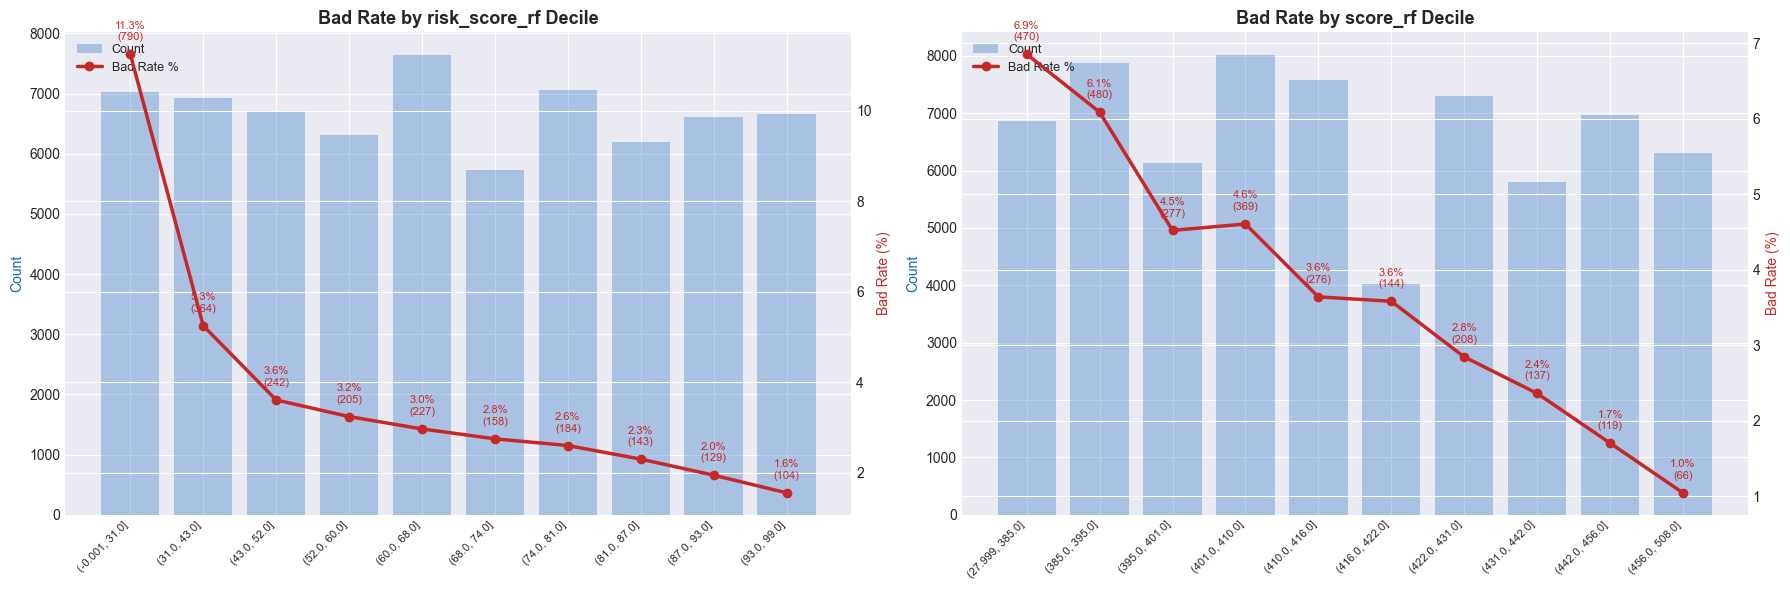

In [70]:
# Score band analysis — bad rate by risk_score_rf deciles
eval_df = df_booked[['risk_score_rf', 'score_rf', 'basel_bad']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, col in enumerate(score_vars):
    data = eval_df[[col, 'basel_bad']].copy()
    data['decile'] = pd.qcut(data[col], q=10, duplicates='drop')
    band = data.groupby('decile', observed=True)['basel_bad'].agg(['mean', 'count', 'sum']).reset_index()
    band['mean'] *= 100
    band = band.sort_values('decile')

    ax2 = axes[idx].twinx()
    x = range(len(band))
    axes[idx].bar(x, band['count'], color='#1565C0', alpha=0.3, label='Count')
    ax2.plot(x, band['mean'], color='#C62828', marker='o', linewidth=2.5, label='Bad Rate %')

    # Annotate bad rate values
    for i, (rate, bad_n) in enumerate(zip(band['mean'], band['sum'])):
        ax2.annotate(f'{rate:.1f}%\n({bad_n:.0f})', (i, rate),
                     textcoords="offset points", xytext=(0, 10),
                     ha='center', fontsize=8, color='#C62828')

    axes[idx].set_title(f'Bad Rate by {col} Decile', fontsize=13, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([str(b)[:15] for b in band['decile']], rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Count', color='#1565C0')
    ax2.set_ylabel('Bad Rate (%)', color='#C62828')

    lines1, labels1 = axes[idx].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[idx].legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

## 18. Information Value (IV) — Feature Predictive Power

IV quantifies how well each feature separates good from bad accounts. Guidelines:
- IV < 0.02: Not useful
- 0.02–0.1: Weak
- 0.1–0.3: Medium
- 0.3–0.5: Strong
- IV > 0.5: Suspicious (overfitting risk)

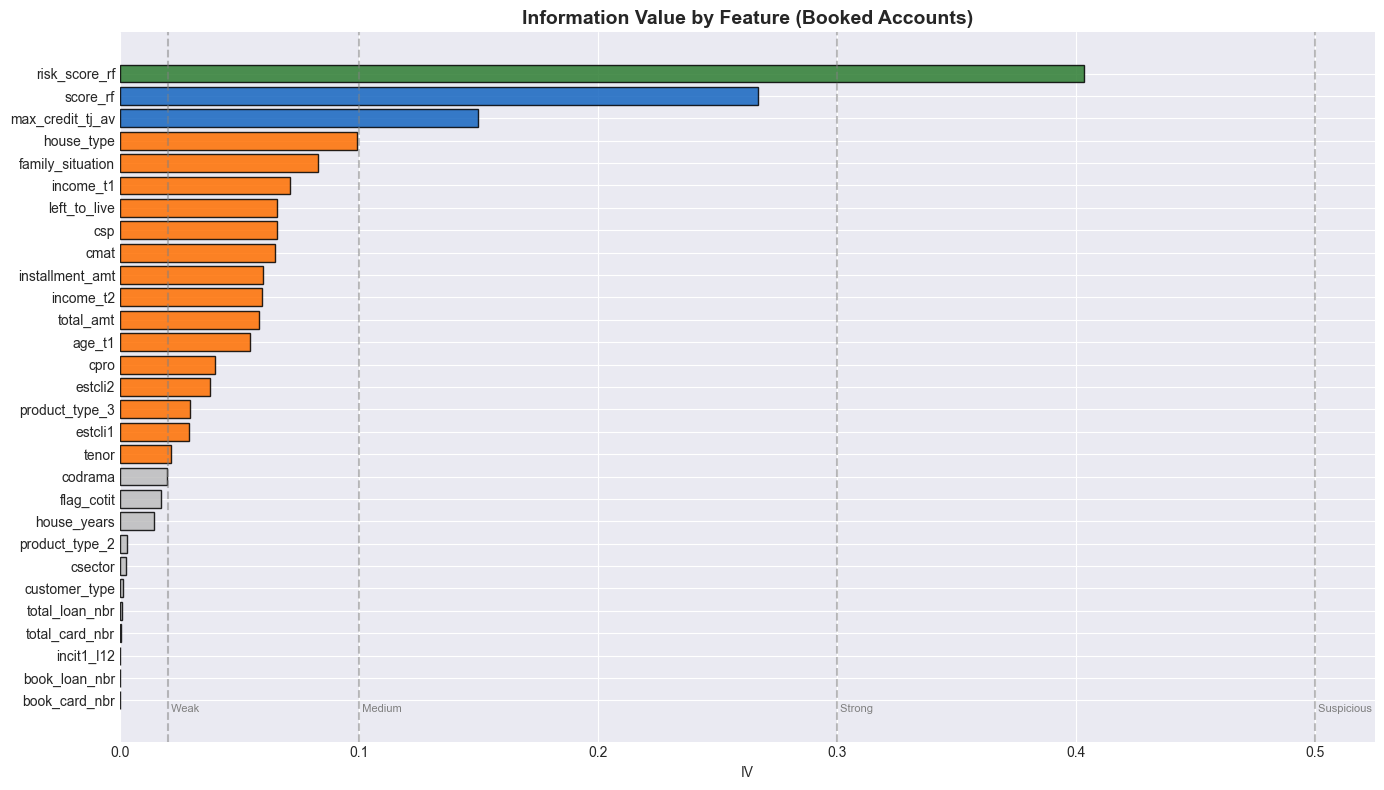

,Feature,IV,Strength
0,risk_score_rf,0.403,Strong
1,score_rf,0.267,Medium
2,max_credit_tj_av,0.150,Medium
3,house_type,0.099,Weak
4,family_situation,0.083,Weak
5,income_t1,0.071,Weak
6,left_to_live,0.066,Weak
7,csp,0.066,Weak
8,cmat,0.065,Weak
9,installment_amt,0.060,Weak


In [71]:
def calc_iv(df, feature, target, bins=10):
    """Calculate Information Value for a feature."""
    data = df[[feature, target]].dropna()
    if data[feature].dtype in ['object', 'string']:
        data['bin'] = data[feature]
    else:
        try:
            data['bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')
        except ValueError:
            data['bin'] = pd.cut(data[feature], bins=min(bins, data[feature].nunique()))

    grouped = data.groupby('bin', observed=True)[target].agg(['sum', 'count'])
    grouped.columns = ['bad', 'total']
    grouped['good'] = grouped['total'] - grouped['bad']

    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    if total_bad == 0 or total_good == 0:
        return 0.0, pd.DataFrame()

    grouped['pct_good'] = grouped['good'] / total_good
    grouped['pct_bad'] = grouped['bad'] / total_bad

    # Avoid log(0) with small epsilon
    eps = 1e-8
    grouped['woe'] = np.log((grouped['pct_good'] + eps) / (grouped['pct_bad'] + eps))
    grouped['iv_bin'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']

    iv = grouped['iv_bin'].sum()
    return iv, grouped

# Calculate IV for all features
iv_features = [c for c in num_cols + cat_cols if c not in ['basel_bad', 'status_name', 'reject_reason']]

iv_results = []
for col in iv_features:
    iv_val, _ = calc_iv(df_booked, col, 'basel_bad')
    iv_results.append({'Feature': col, 'IV': iv_val})

iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False).reset_index(drop=True)

# Classify IV strength
iv_df['Strength'] = pd.cut(
    iv_df['IV'],
    bins=[-np.inf, 0.02, 0.1, 0.3, 0.5, np.inf],
    labels=['Not useful', 'Weak', 'Medium', 'Strong', 'Suspicious']
)

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
colors = iv_df['Strength'].map({
    'Not useful': '#BDBDBD', 'Weak': '#FF6F00', 'Medium': '#1565C0',
    'Strong': '#2E7D32', 'Suspicious': '#C62828'
})
ax.barh(iv_df['Feature'], iv_df['IV'], color=colors, edgecolor='black', alpha=0.85)
ax.set_title('Information Value by Feature (Booked Accounts)', fontsize=14, fontweight='bold')
ax.set_xlabel('IV')

# Reference lines
for threshold, label in [(0.02, 'Weak'), (0.1, 'Medium'), (0.3, 'Strong'), (0.5, 'Suspicious')]:
    ax.axvline(threshold, color='gray', linestyle='--', alpha=0.5)
    ax.text(threshold, len(iv_df) - 0.5, f' {label}', fontsize=8, color='gray')

ax.invert_yaxis()
plt.tight_layout()
plt.show()

iv_df

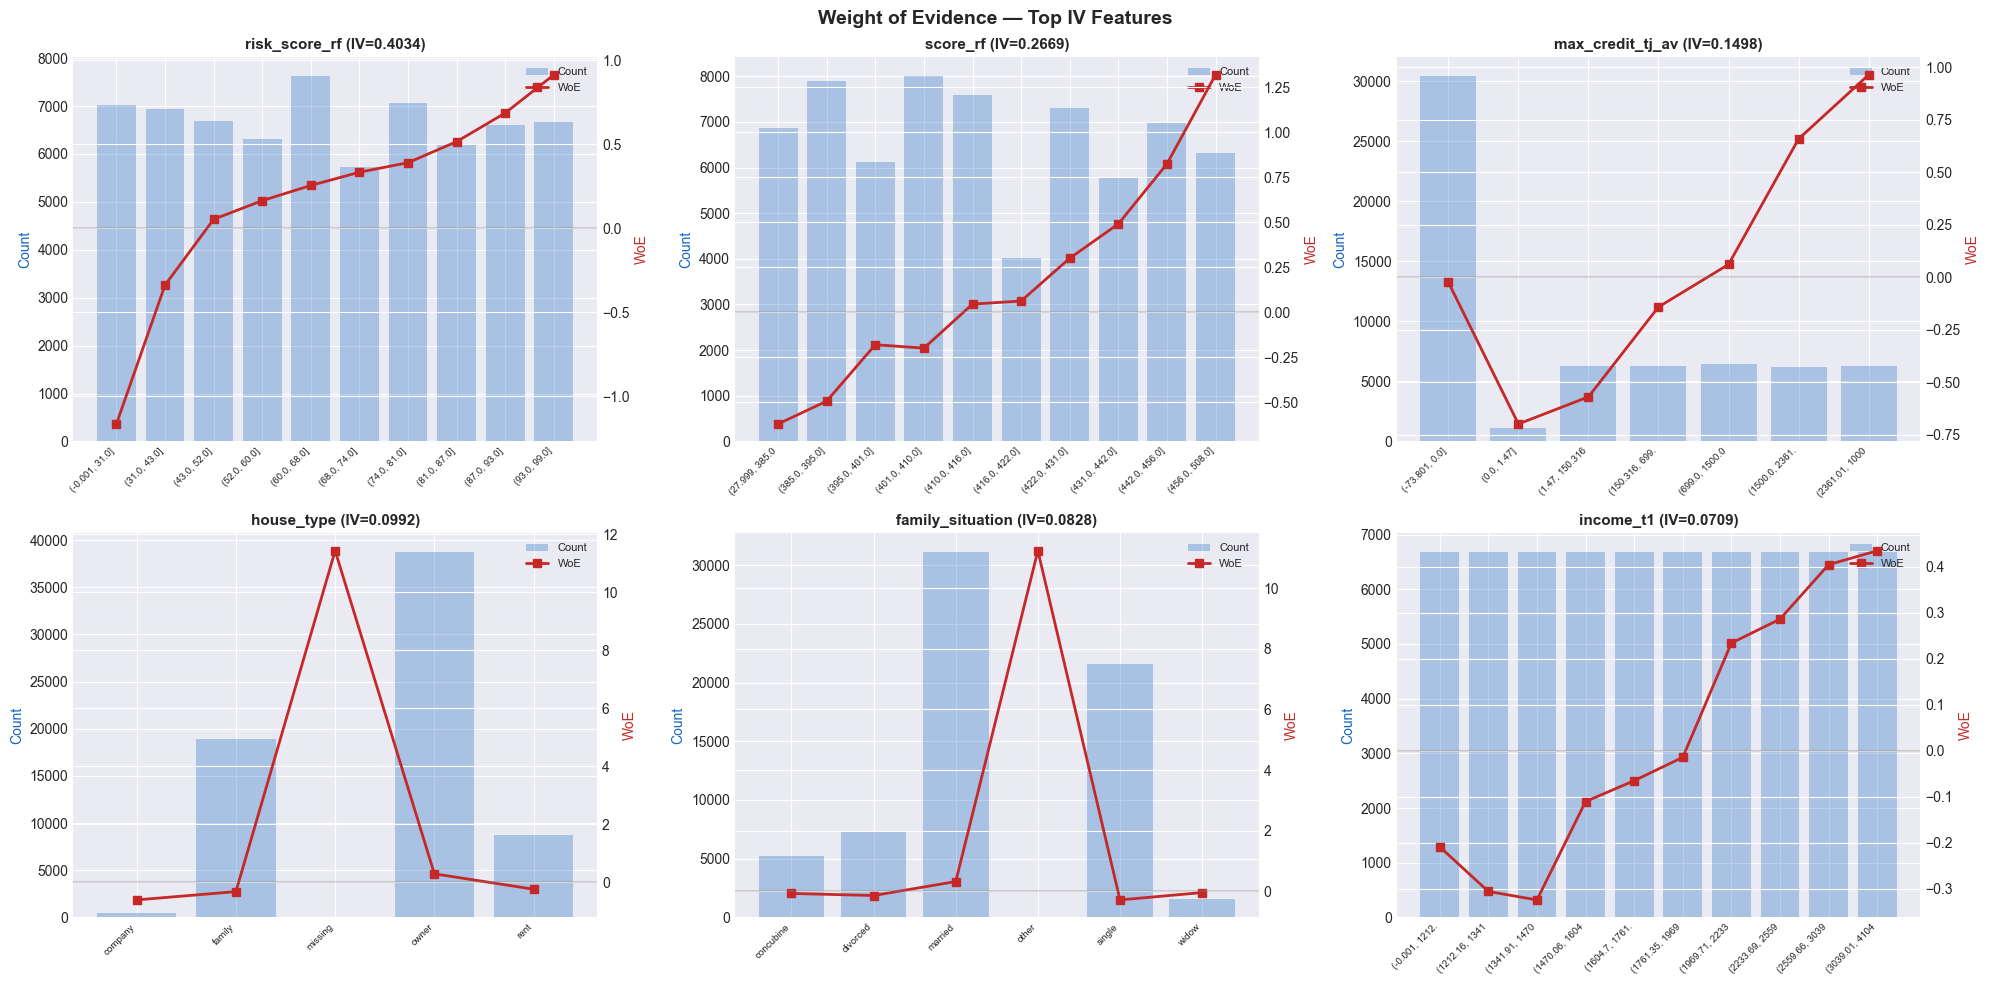

In [72]:
# WoE detail for top IV features
top_iv_features = iv_df.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(top_iv_features):
    _, woe_detail = calc_iv(df_booked, col, 'basel_bad')
    if woe_detail.empty:
        continue

    ax2 = axes[idx].twinx()
    x = range(len(woe_detail))
    axes[idx].bar(x, woe_detail['total'], color='#1565C0', alpha=0.3, label='Count')
    ax2.plot(x, woe_detail['woe'], color='#C62828', marker='s', linewidth=2, label='WoE')
    ax2.axhline(0, color='gray', linestyle='-', alpha=0.3)

    axes[idx].set_title(f'{col} (IV={iv_df.loc[iv_df["Feature"]==col, "IV"].values[0]:.4f})',
                        fontsize=11, fontweight='bold')
    labels = [str(b)[:14] for b in woe_detail.index]
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    axes[idx].set_ylabel('Count', color='#1565C0')
    ax2.set_ylabel('WoE', color='#C62828')

    lines1, labels1 = axes[idx].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[idx].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Weight of Evidence — Top IV Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 19. Bivariate Bad Rate Analysis

Bad rate by combinations of key features (booked accounts only).

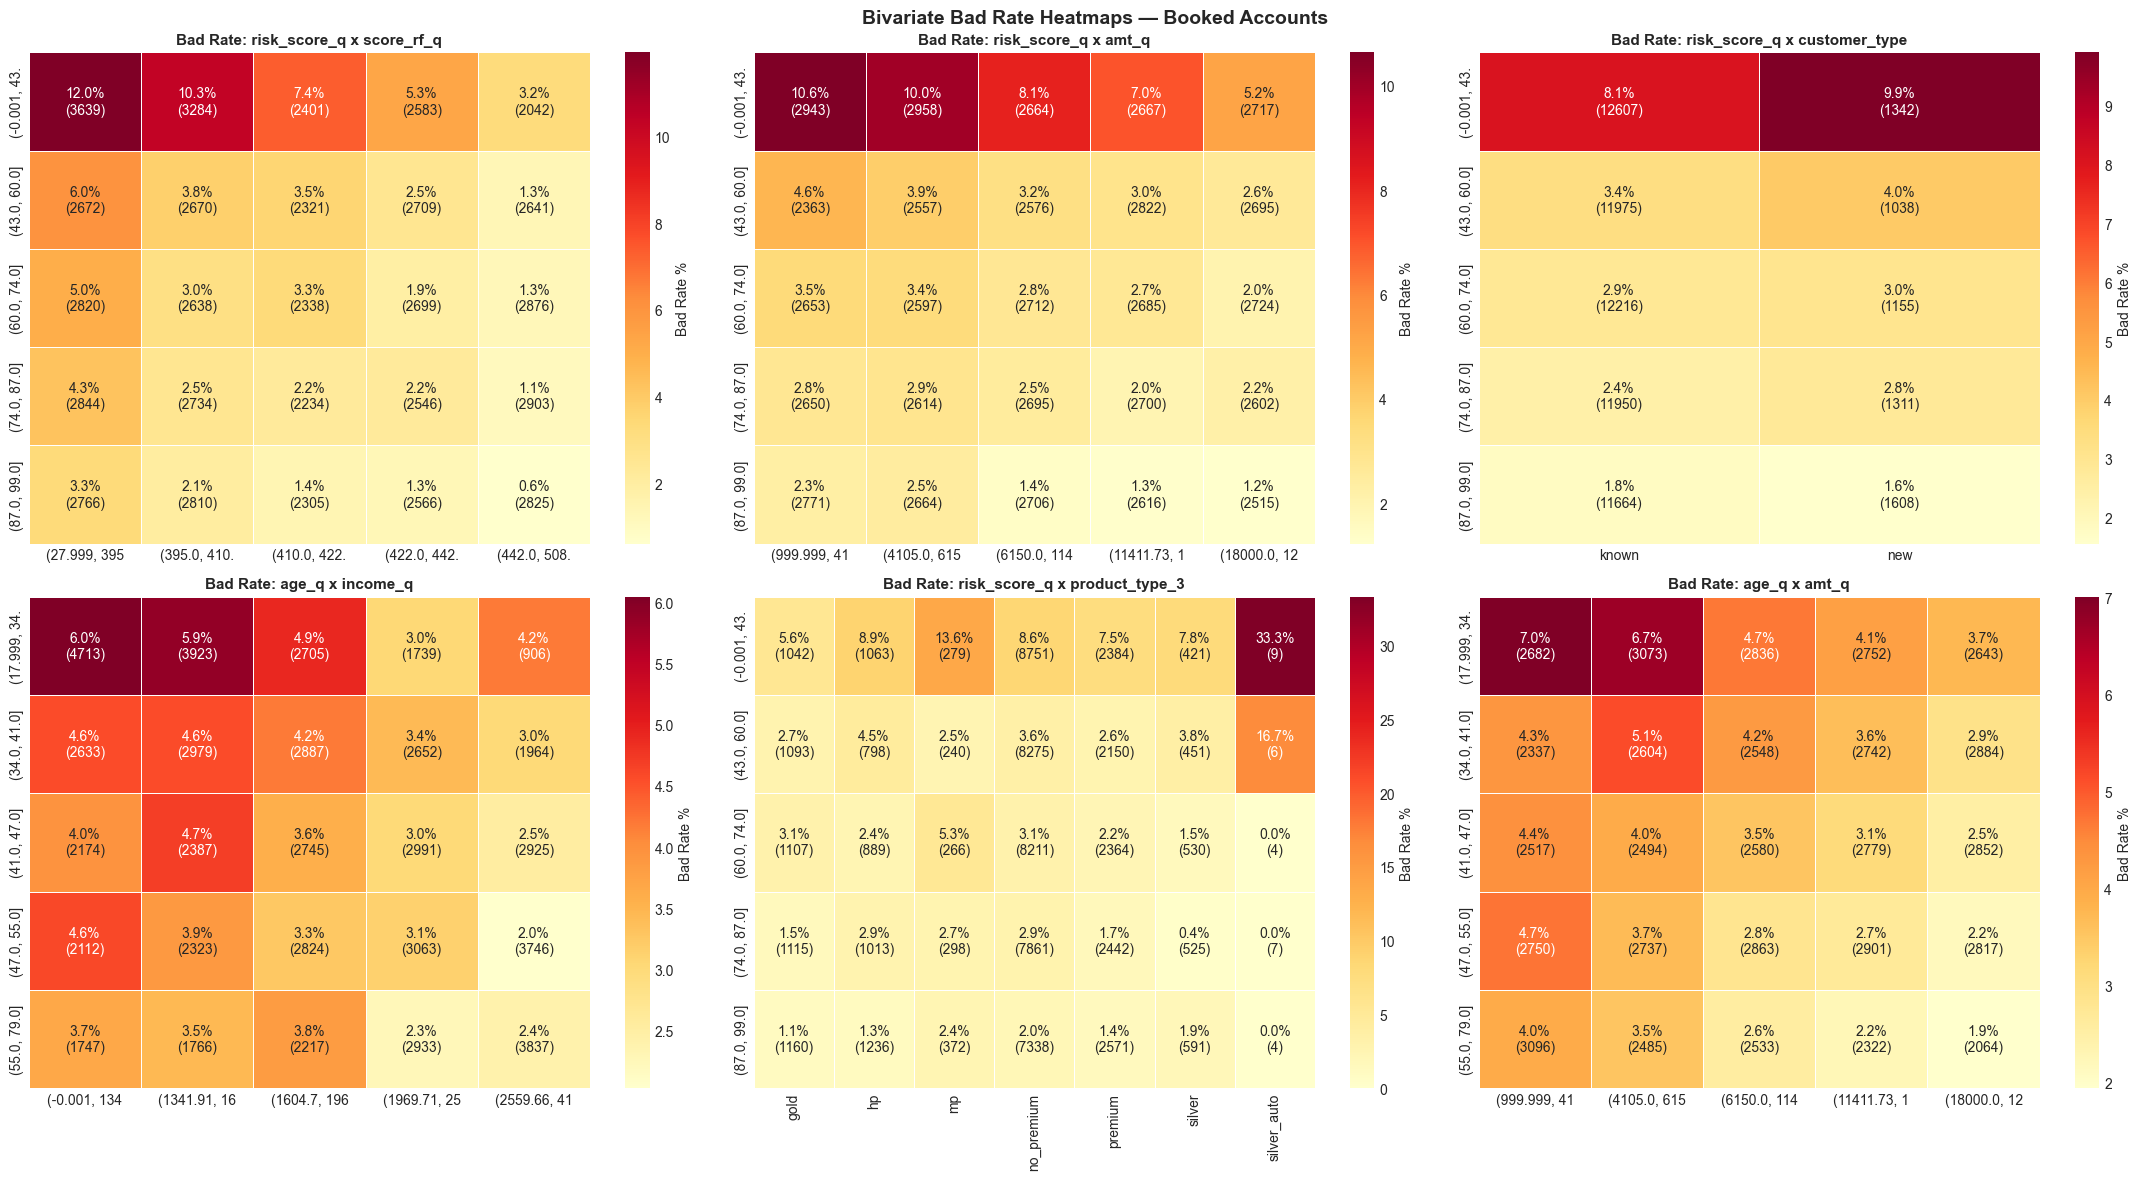

In [73]:
# Create binned versions of key numerical features for cross-tabulation
df_bv = df_booked[['risk_score_rf', 'score_rf', 'total_amt', 'income_t1',
                    'age_t1', 'tenor', 'customer_type', 'product_type_3',
                    'basel_bad']].dropna(subset=['basel_bad']).copy()

df_bv['risk_score_q'] = pd.qcut(df_bv['risk_score_rf'], q=5, duplicates='drop')
df_bv['score_rf_q'] = pd.qcut(df_bv['score_rf'], q=5, duplicates='drop')
df_bv['amt_q'] = pd.qcut(df_bv['total_amt'], q=5, duplicates='drop')
df_bv['income_q'] = pd.qcut(df_bv['income_t1'], q=5, duplicates='drop')
df_bv['age_q'] = pd.qcut(df_bv['age_t1'], q=5, duplicates='drop')

# Bad rate heatmaps for key feature pairs
pairs = [
    ('risk_score_q', 'score_rf_q'),
    ('risk_score_q', 'amt_q'),
    ('risk_score_q', 'customer_type'),
    ('age_q', 'income_q'),
    ('risk_score_q', 'product_type_3'),
    ('age_q', 'amt_q'),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for idx, (row_var, col_var) in enumerate(pairs):
    ct = df_bv.groupby([row_var, col_var], observed=True)['basel_bad'].agg(['mean', 'count']).reset_index()
    ct_rate = ct.pivot_table(index=row_var, columns=col_var, values='mean') * 100
    ct_count = ct.pivot_table(index=row_var, columns=col_var, values='count')

    # Create annotation with rate and count
    annot = ct_rate.copy().astype(str)
    for r in ct_rate.index:
        for c in ct_rate.columns:
            rate = ct_rate.loc[r, c] if pd.notna(ct_rate.loc[r, c]) else 0
            count = ct_count.loc[r, c] if pd.notna(ct_count.loc[r, c]) else 0
            annot.loc[r, c] = f'{rate:.1f}%\n({count:.0f})'

    # Shorten labels
    ct_rate.index = [str(x)[:12] for x in ct_rate.index]
    ct_rate.columns = [str(x)[:12] for x in ct_rate.columns]
    annot.index = ct_rate.index
    annot.columns = ct_rate.columns

    sns.heatmap(ct_rate, annot=annot, fmt='', cmap='YlOrRd', ax=axes[idx],
                linewidths=0.5, cbar_kws={'label': 'Bad Rate %'})
    axes[idx].set_title(f'Bad Rate: {row_var} x {col_var}', fontsize=11, fontweight='bold')

plt.suptitle('Bivariate Bad Rate Heatmaps — Booked Accounts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 20. Vintage Analysis

Bad rate by booking month (vintage) to detect cohort-level trends.

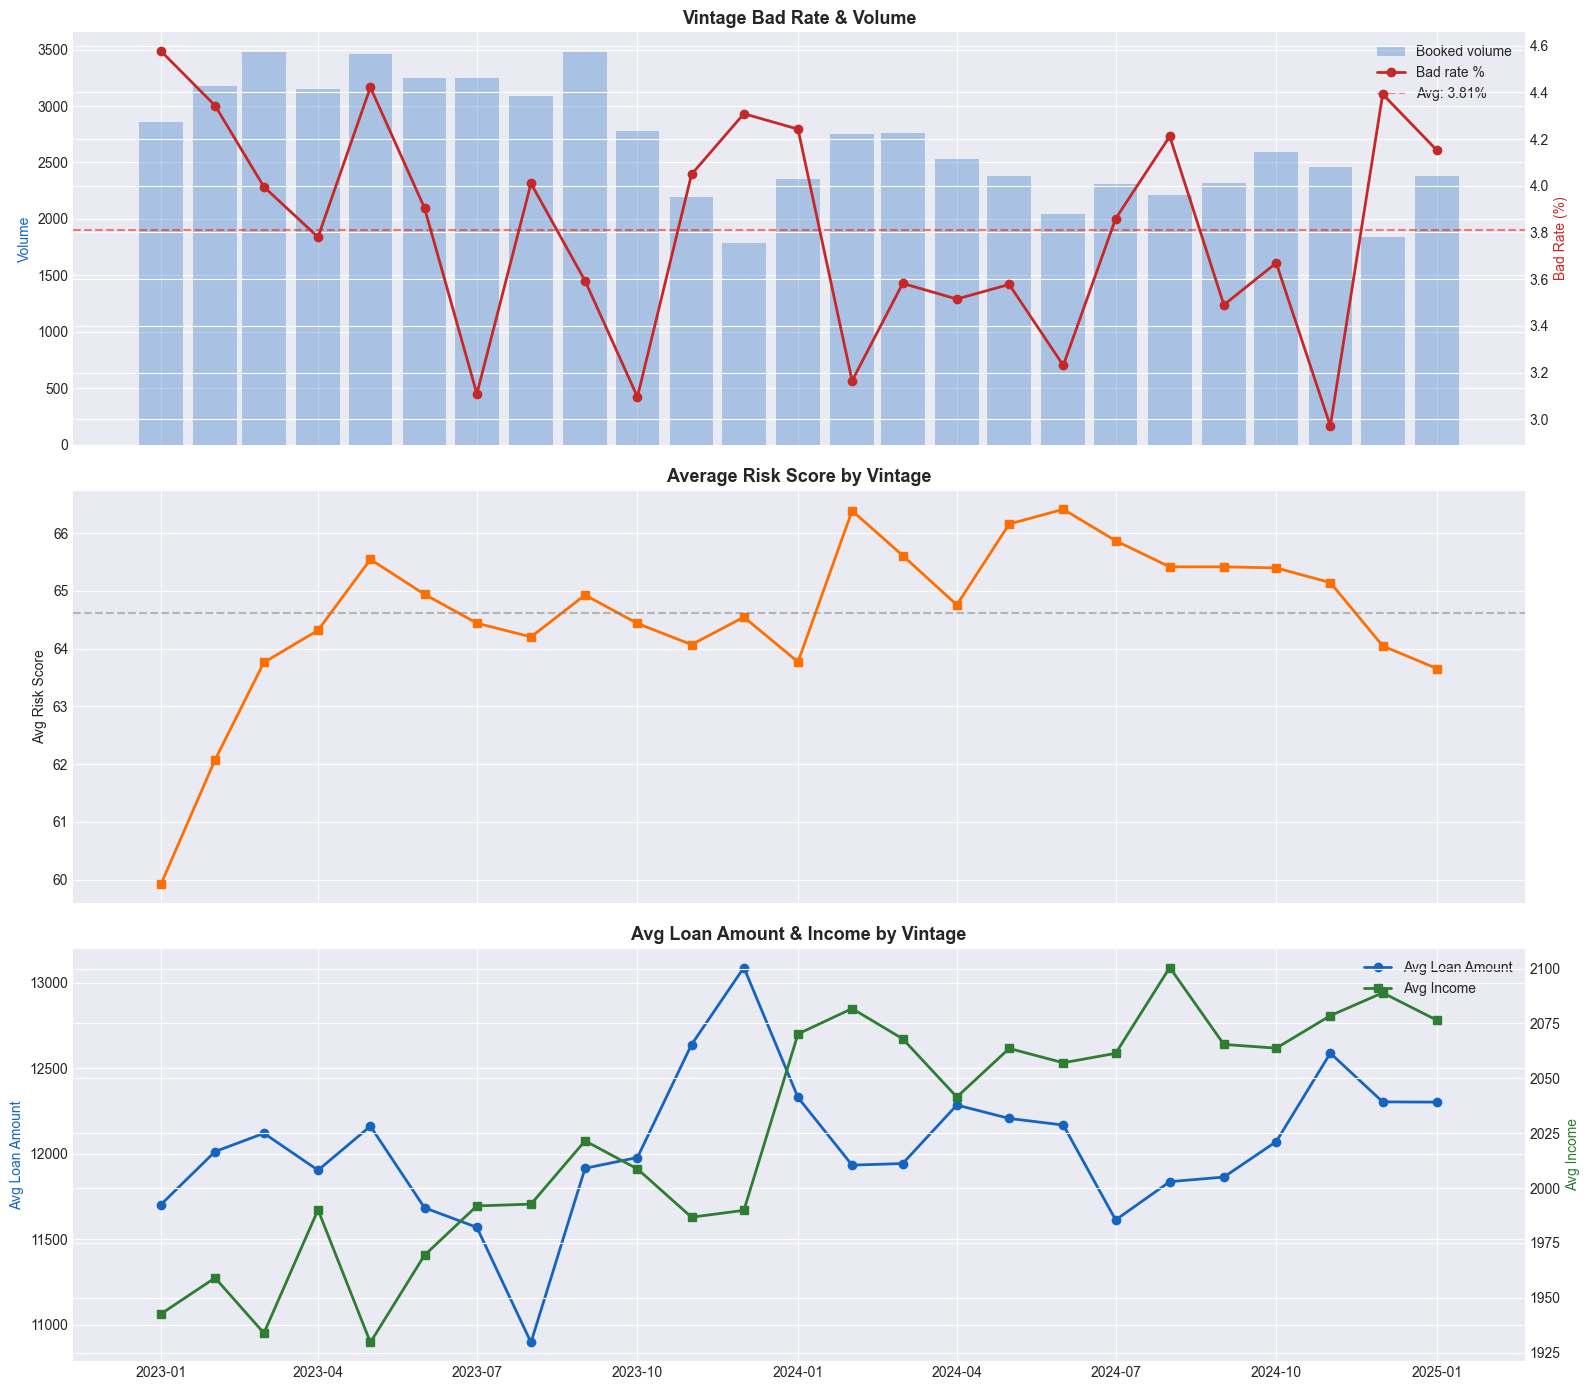

,mis_date,total,n_bad,bad_rate_pct,avg_risk_score,avg_amount
0,2023-01-01,2862,131.000,4.580,59.920,11703.760
1,2023-02-01,3177,138.000,4.340,62.080,12013.310
2,2023-03-01,3479,139.000,4.000,63.760,12120.070
3,2023-04-01,3148,119.000,3.780,64.320,11904.340
4,2023-05-01,3460,153.000,4.420,65.540,12161.470
5,2023-06-01,3252,127.000,3.910,64.940,11685.100
6,2023-07-01,3249,101.000,3.110,64.440,11570.580
7,2023-08-01,3092,124.000,4.010,64.200,10898.210
8,2023-09-01,3479,125.000,3.590,64.930,11915.810
9,2023-10-01,2778,86.000,3.100,64.440,11978.530


In [74]:
# Vintage analysis — bad rate and volume by booking month
vintage = (
    df_booked
    .groupby(pd.Grouper(key='mis_date', freq='MS'))
    .agg(
        total=('basel_bad', 'count'),
        n_bad=('basel_bad', 'sum'),
        bad_rate=('basel_bad', 'mean'),
        avg_risk_score=('risk_score_rf', 'mean'),
        avg_amount=('total_amt', 'mean'),
        avg_income=('income_t1', 'mean'),
    )
    .reset_index()
)
vintage['bad_rate_pct'] = vintage['bad_rate'] * 100

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# Bad rate with volume
ax2 = axes[0].twinx()
axes[0].bar(vintage['mis_date'], vintage['total'], width=25,
            color='#1565C0', alpha=0.3, label='Booked volume')
ax2.plot(vintage['mis_date'], vintage['bad_rate_pct'], color='#C62828',
         marker='o', linewidth=2, label='Bad rate %')
ax2.axhline(vintage['bad_rate_pct'].mean(), color='red', linestyle='--', alpha=0.5,
            label=f'Avg: {vintage["bad_rate_pct"].mean():.2f}%')
axes[0].set_ylabel('Volume', color='#1565C0')
ax2.set_ylabel('Bad Rate (%)', color='#C62828')
axes[0].set_title('Vintage Bad Rate & Volume', fontsize=13, fontweight='bold')
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Average risk score by vintage
axes[1].plot(vintage['mis_date'], vintage['avg_risk_score'], color='#FF6F00',
             marker='s', linewidth=2)
axes[1].axhline(vintage['avg_risk_score'].mean(), color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Avg Risk Score')
axes[1].set_title('Average Risk Score by Vintage', fontsize=13, fontweight='bold')

# Average loan amount and income by vintage
axes[2].plot(vintage['mis_date'], vintage['avg_amount'], color='#1565C0',
             marker='o', linewidth=2, label='Avg Loan Amount')
ax3 = axes[2].twinx()
ax3.plot(vintage['mis_date'], vintage['avg_income'], color='#2E7D32',
         marker='s', linewidth=2, label='Avg Income')
axes[2].set_ylabel('Avg Loan Amount', color='#1565C0')
ax3.set_ylabel('Avg Income', color='#2E7D32')
axes[2].set_title('Avg Loan Amount & Income by Vintage', fontsize=13, fontweight='bold')
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

vintage[['mis_date', 'total', 'n_bad', 'bad_rate_pct', 'avg_risk_score', 'avg_amount']].round(2)

## 21. Population Stability Index (PSI)

Measures how much the score distribution of booked accounts has shifted over time. PSI > 0.25 signals a significant population shift.

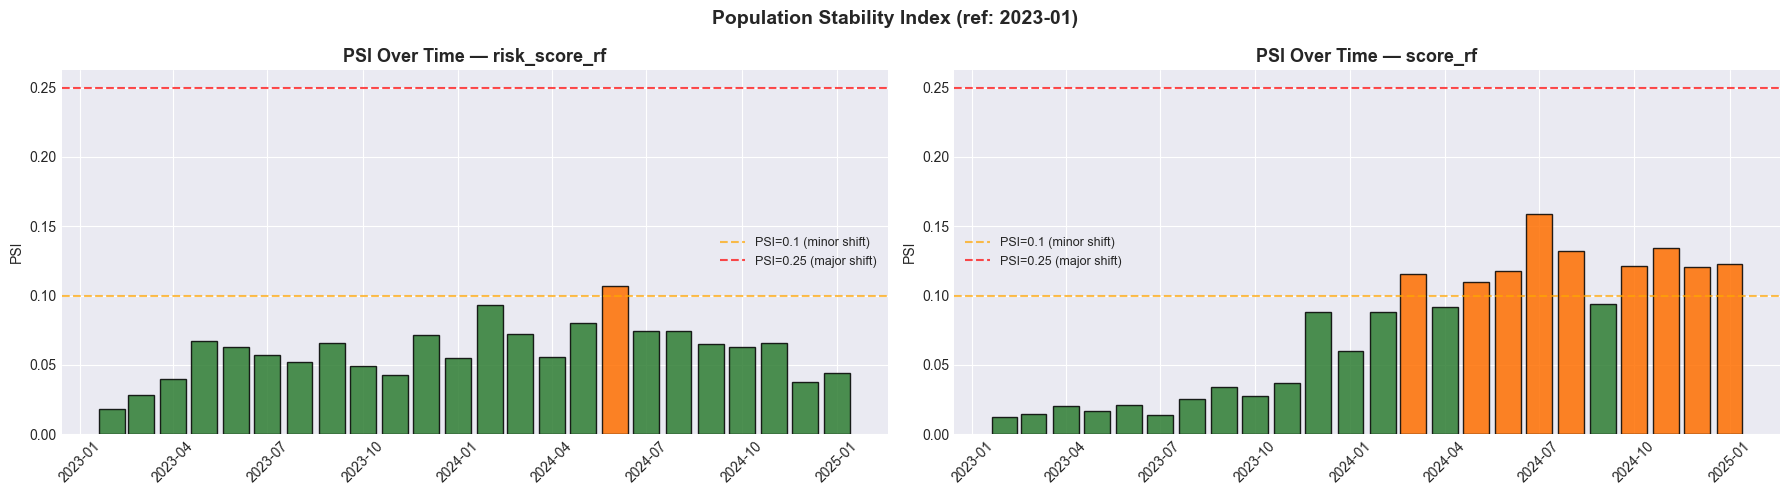

In [75]:
def calc_psi(expected, actual, bins=10):
    """Calculate PSI between two distributions."""
    breakpoints = np.linspace(0, 100, bins + 1)
    expected_pcts = np.percentile(expected, breakpoints)

    expected_counts = np.histogram(expected, bins=expected_pcts)[0]
    actual_counts = np.histogram(actual, bins=expected_pcts)[0]

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    eps = 1e-8
    psi = np.sum((actual_pct - expected_pct) * np.log((actual_pct + eps) / (expected_pct + eps)))
    return psi

# Use first month as reference for booked accounts
df_booked_scored = df_booked[['mis_date', 'risk_score_rf', 'score_rf']].dropna()
months = sorted(df_booked_scored['mis_date'].unique())
ref_month = months[0]
ref_data = df_booked_scored[df_booked_scored['mis_date'] == ref_month]

psi_results = []
for month in months[1:]:
    month_data = df_booked_scored[df_booked_scored['mis_date'] == month]
    for col in ['risk_score_rf', 'score_rf']:
        psi_val = calc_psi(ref_data[col].values, month_data[col].values)
        psi_results.append({'month': month, 'feature': col, 'PSI': psi_val, 'n': len(month_data)})

psi_df = pd.DataFrame(psi_results)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for idx, col in enumerate(['risk_score_rf', 'score_rf']):
    subset = psi_df[psi_df['feature'] == col]
    axes[idx].bar(subset['month'], subset['PSI'], width=25,
                  color=['#C62828' if p > 0.25 else '#FF6F00' if p > 0.1 else '#2E7D32'
                         for p in subset['PSI']],
                  edgecolor='black', alpha=0.85)
    axes[idx].axhline(0.1, color='orange', linestyle='--', alpha=0.7, label='PSI=0.1 (minor shift)')
    axes[idx].axhline(0.25, color='red', linestyle='--', alpha=0.7, label='PSI=0.25 (major shift)')
    axes[idx].set_title(f'PSI Over Time — {col}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('PSI')
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle(f'Population Stability Index (ref: {ref_month.strftime("%Y-%m")})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 22. Risk Segmentation — Booked Accounts

Score-based risk segments with bad rate, volume, and key feature averages.

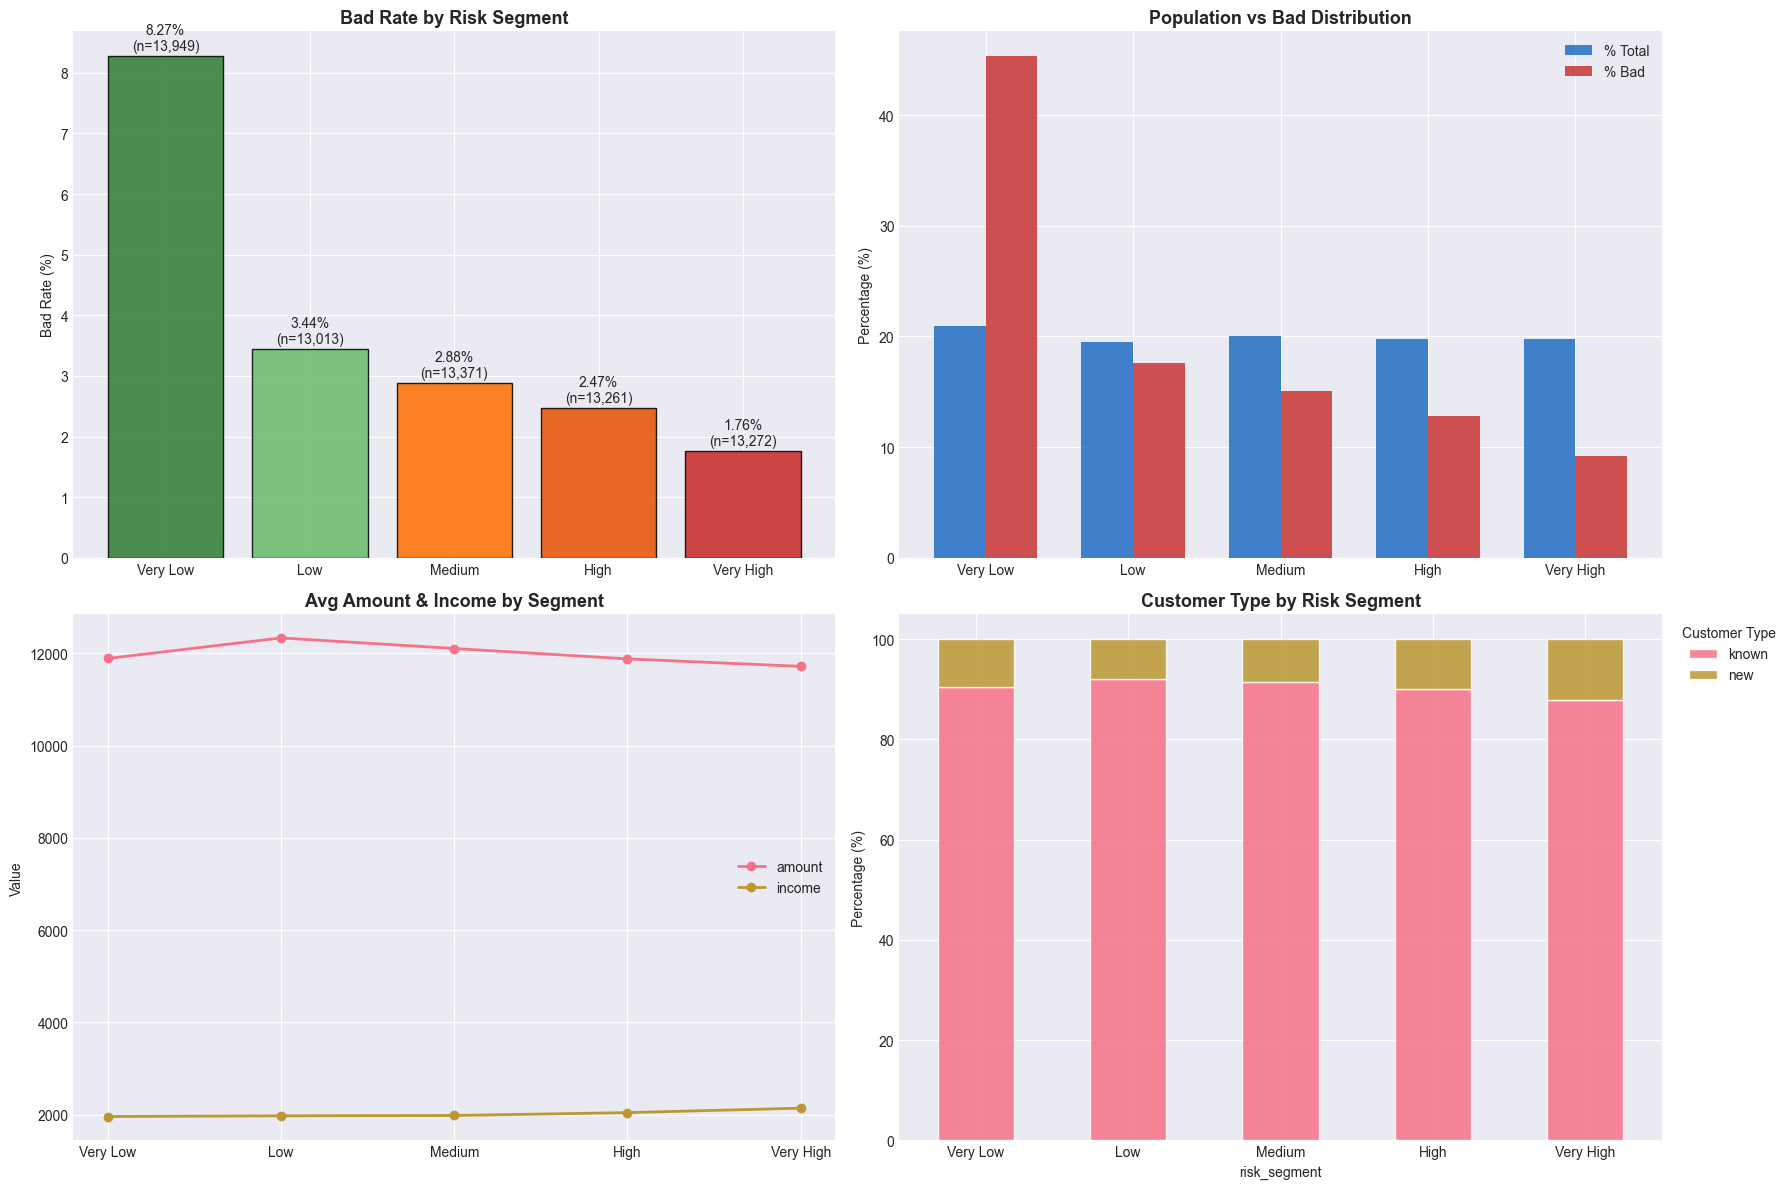

,risk_segment,n,pct_total,n_bad,pct_bad,bad_rate_pct,avg_risk_score,avg_score_rf,avg_amount,avg_income,avg_age
0,Very Low,13949,20.900,1154.000,45.300,8.270,29.860,414.270,11887.060,1958.830,41.660
1,Low,13013,19.500,447.000,17.600,3.440,52.150,419.670,12332.690,1973.780,42.060
2,Medium,13371,20.000,385.000,15.100,2.880,67.590,420.050,12103.110,1981.650,43.370
3,High,13261,19.800,327.000,12.800,2.470,81.100,419.960,11878.090,2042.940,47.210
4,Very High,13272,19.800,233.000,9.200,1.760,93.630,419.840,11715.570,2139.890,50.170


In [76]:
# Risk segmentation by risk_score_rf quintiles
df_seg = df_booked[['risk_score_rf', 'score_rf', 'basel_bad', 'total_amt',
                     'installment_amt', 'income_t1', 'age_t1', 'tenor',
                     'customer_type', 'product_type_3']].dropna(subset=['risk_score_rf', 'basel_bad']).copy()

df_seg['risk_segment'] = pd.qcut(
    df_seg['risk_score_rf'], q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    duplicates='drop'
)

# Segment summary table
seg_summary = df_seg.groupby('risk_segment', observed=True).agg(
    n=('basel_bad', 'count'),
    n_bad=('basel_bad', 'sum'),
    bad_rate=('basel_bad', 'mean'),
    avg_risk_score=('risk_score_rf', 'mean'),
    avg_score_rf=('score_rf', 'mean'),
    avg_amount=('total_amt', 'mean'),
    avg_installment=('installment_amt', 'mean'),
    avg_income=('income_t1', 'mean'),
    avg_age=('age_t1', 'mean'),
    avg_tenor=('tenor', 'mean'),
).reset_index()

seg_summary['bad_rate_pct'] = (seg_summary['bad_rate'] * 100).round(2)
seg_summary['pct_total'] = (seg_summary['n'] / seg_summary['n'].sum() * 100).round(1)
seg_summary['pct_bad'] = (seg_summary['n_bad'] / seg_summary['n_bad'].sum() * 100).round(1)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Bad rate by segment
colors_seg = ['#2E7D32', '#66BB6A', '#FF6F00', '#E65100', '#C62828']
axes[0, 0].bar(seg_summary['risk_segment'], seg_summary['bad_rate_pct'],
               color=colors_seg, edgecolor='black', alpha=0.85)
for i, (rate, n) in enumerate(zip(seg_summary['bad_rate_pct'], seg_summary['n'])):
    axes[0, 0].text(i, rate + 0.1, f'{rate:.2f}%\n(n={n:,})', ha='center', fontsize=10)
axes[0, 0].set_title('Bad Rate by Risk Segment', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Bad Rate (%)')

# Volume and bad distribution
x = np.arange(len(seg_summary))
w = 0.35
axes[0, 1].bar(x - w/2, seg_summary['pct_total'], w, label='% Total', color='#1565C0', alpha=0.8)
axes[0, 1].bar(x + w/2, seg_summary['pct_bad'], w, label='% Bad', color='#C62828', alpha=0.8)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(seg_summary['risk_segment'])
axes[0, 1].set_title('Population vs Bad Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].legend()

# Average features by segment
features_to_show = ['avg_amount', 'avg_income']
for feat in features_to_show:
    axes[1, 0].plot(seg_summary['risk_segment'], seg_summary[feat],
                    marker='o', linewidth=2, label=feat.replace('avg_', ''))
axes[1, 0].set_title('Avg Amount & Income by Segment', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Value')
axes[1, 0].legend()

# Customer type breakdown by segment
ct_seg = pd.crosstab(df_seg['risk_segment'], df_seg['customer_type'], normalize='index') * 100
ct_seg.plot(kind='bar', stacked=True, ax=axes[1, 1], alpha=0.85, edgecolor='white')
axes[1, 1].set_title('Customer Type by Risk Segment', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].legend(title='Customer Type', bbox_to_anchor=(1.01, 1))
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

seg_summary[['risk_segment', 'n', 'pct_total', 'n_bad', 'pct_bad', 'bad_rate_pct',
             'avg_risk_score', 'avg_score_rf', 'avg_amount', 'avg_income', 'avg_age']].round(2)

## 23. Correlation with Default — Booked Accounts

Feature correlations with `basel_bad` and inter-feature correlations within the booked population.

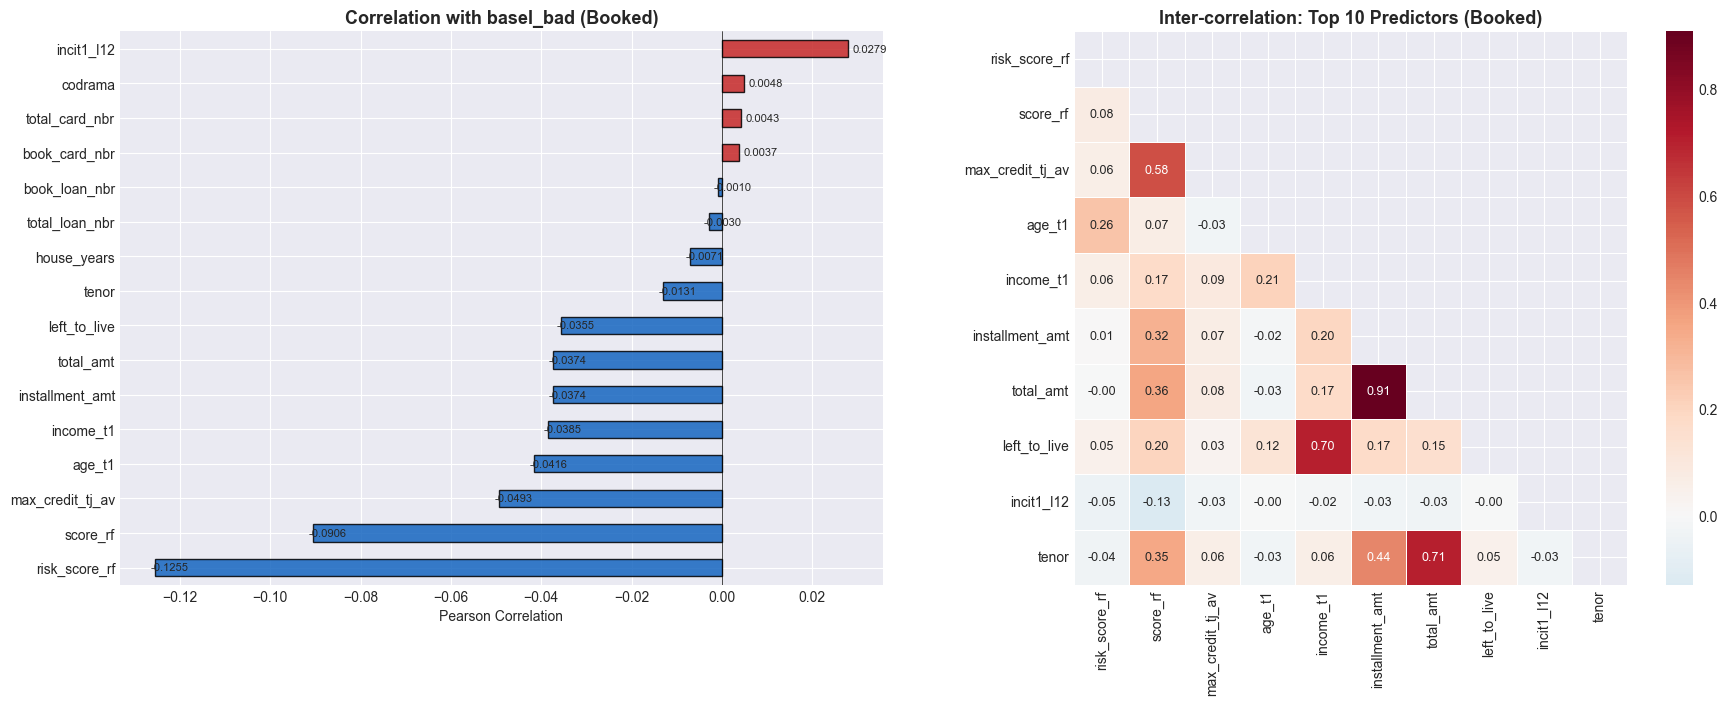

In [77]:
# Correlation of features with basel_bad (booked only)
corr_target_cols = [c for c in num_cols if c != 'basel_bad' and df_booked[c].notna().mean() > 0.3]
target_corr = df_booked[corr_target_cols + ['basel_bad']].corr()['basel_bad'].drop('basel_bad').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart of correlations with bad
colors_corr = ['#C62828' if v > 0 else '#1565C0' for v in target_corr.values]
target_corr.plot(kind='barh', ax=axes[0], color=colors_corr, edgecolor='black', alpha=0.85)
axes[0].set_title('Correlation with basel_bad (Booked)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')
axes[0].axvline(0, color='black', linewidth=0.5)
for i, v in enumerate(target_corr.values):
    axes[0].text(v + 0.001 * np.sign(v), i, f'{v:.4f}', va='center', fontsize=8)

# Correlation heatmap among top predictors (booked only)
top_pred = target_corr.abs().nlargest(10).index.tolist()
corr_top = df_booked[top_pred].corr()
mask = np.triu(np.ones_like(corr_top, dtype=bool))
sns.heatmap(corr_top, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], square=True, linewidths=0.5, annot_kws={'size': 9})
axes[1].set_title('Inter-correlation: Top 10 Predictors (Booked)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()